# Pipeline Comparison: MIMIC_Extract vs EHR-Dataset-Processing

Side-by-side holdout comparison on the shared MIMIC-III patient cohort.
Both pipelines are aligned on hospital mortality, seven bedside vitals,
and a 24-hour observation window. Identical logistic regression classifiers
are trained on matched feature sets to isolate the effect of preprocessing.

## Setup & Imports

In [1]:
import sys
import types
import warnings
import pickle
import functools
from pathlib import Path
from typing import List, Tuple

# EHR-Dataset-Processing must be importable so RecordEHR can be unpickled.
# ehr_record.py imports torch at module level; stub it out since to_tensor()
# is never called in this notebook.  scipy.array_api_compat probes torch.Tensor
# so it must be a real class (issubclass-safe), not None.
if 'torch' not in sys.modules:
    _torch_stub = types.ModuleType('torch')
    _torch_stub.Tensor = type('Tensor', (), {})   # class, not None
    _torch_stub.tensor = lambda *a, **kw: None
    _torch_stub.save   = lambda *a, **kw: None
    _torch_stub.load   = lambda *a, **kw: None
    sys.modules['torch'] = _torch_stub

sys.path.insert(0, str(Path('EHR-Dataset-Processing').resolve()))

from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
from scipy.stats import binom

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from tabulate import tabulate

plt.rcParams.update({
    'figure.facecolor':  '#191a1c',
    'axes.facecolor':    '#191a1c',
    'axes.edgecolor':    '#ffffff',
    'axes.labelcolor':   '#ffffff',
    'xtick.color':       '#ffffff',
    'ytick.color':       '#ffffff',
    'text.color':        '#ffffff',
    'grid.color':        '#3a3b3d',
    'grid.linestyle':    ':',
    'grid.linewidth':    0.5,
    'legend.facecolor':  '#2a2b2d',
    'legend.edgecolor':  '#ffffff',
})

## Configuration

In [2]:
MIMIC_HDF = Path('../pipelines/MIMIC_Extract/data/curated/baseline_nofilters/all_hourly_data.h5')
EHR_PKL   = Path('../pipelines/EHR-Dataset-Processing/Data/mimic-iii/processed_record_ehr.pkl')

AGG_METHODS = [
    'mean', 'median', 'standard deviation', 'mean deviation', 'maximum deviation'
]

SEEDS      = [22, 985, 439, 81]
TEST_SIZE  = 0.2
MODEL_KWARGS = dict(max_iter=500, solver='liblinear', random_state=0)

# EHR column name → MIMIC_Extract column name
VITAL_NAME_MAP = {'respiration rate': 'respiratory rate'}

VITAL_NAMES = [
    'heart rate',
    'systolic blood pressure',
    'diastolic blood pressure',
    'mean blood pressure',
    'respiratory rate',
    'temperature',
    'oxygen saturation',
]
EHR_DATA_ROOT      = Path('../pipelines/EHR-Dataset-Processing/Data/mimic-iii')
MIMIC_STATS_PATH   = Path('../pipelines/MIMIC_Extract/experiment_stats.json')
MIMIC_SCENARIO_DIR = Path('../pipelines/MIMIC_Extract/data/scenario_analysis')

EHR_FILTER_LABELS = [
    'raw', 'heart rate', 'systolic blood pressure', 'diastolic blood pressure',
    'mean blood pressure', 'respiration rate', 'temperature', 'oxygen saturation',
    'fill missing data', 'long missing segment', 'long gap', 'high invalid data',
    'all vitals',
]

MIMIC_SCENARIO_LABELS = [
    'raw', 'age35_range5', 'age35_range10', 'age35_range15',
    'age45_range5', 'age45_range10', 'age45_range15',
    'age55_range5', 'age55_range10', 'age55_range15',
    'min48hr', 'min18age', 'minperc5',
]


## Aurora Visualization Helpers

All plots use the Aurora dark theme, functions are mirrored from
`EHR-Dataset-Processing/Managers/visualization_manager.py`.

In [3]:
def generate_hex_gradient(colours: List[str], gradient_length: int) -> List[str]:
    if len(colours) < 2:
        raise ValueError('At least two colors required.')
    if gradient_length == 1:
        return [colours[0]]
    rgb_colors = np.array([mcolors.to_rgb(c) for c in colours])
    segments   = len(colours) - 1
    gradient   = []
    for i in range(gradient_length):
        pos         = i / (gradient_length - 1)
        seg         = min(int(pos * segments), segments - 1)
        seg_pos     = (pos - seg / segments) * segments
        interp      = rgb_colors[seg] + (rgb_colors[seg + 1] - rgb_colors[seg]) * seg_pos
        gradient.append(mcolors.to_hex(interp))
    return gradient

_AURORA = ['#191a1c', '#724ed5', '#4ED595']
_BG     = '#191a1c'

def _aurora_cmap():
    g = generate_hex_gradient(_AURORA, 20)
    return mcolors.LinearSegmentedColormap.from_list('aurora', g, N=20)

def generate_3d_plot(df: pd.DataFrame, title: str = '3D Surface',
                     x_title: str = '', y_title: str = '', z_title: str = '',
                     background_colour: str = _BG):
    if not np.issubdtype(df.values.dtype, np.number):
        raise ValueError('DataFrame must be numeric.')
    rows, cols = df.shape
    X, Y = np.meshgrid(np.arange(cols), np.arange(rows))
    Z    = df.values.astype(float)
    X_s  = np.linspace(0, cols - 1, cols * 10)
    Y_s  = np.linspace(0, rows - 1, rows * 10)
    Xg, Yg = np.meshgrid(X_s, Y_s)
    Zg = griddata(np.column_stack((X.flatten(), Y.flatten())), Z.flatten(),
                  (Xg, Yg), method='cubic')
    cmap   = _aurora_cmap()
    fig    = plt.figure(figsize=(12, 6), facecolor=background_colour)
    ax     = fig.add_subplot(111, projection='3d', facecolor=background_colour)
    surf   = ax.plot_surface(Xg, Yg, Zg, cmap=cmap, edgecolor='none')
    ax.set_xlabel(x_title); ax.set_ylabel(y_title); ax.set_zlabel(z_title)
    ax.set_xticks(np.arange(cols))
    ax.set_xticklabels(df.columns, rotation=45, ha='right')
    for pane in (ax.xaxis, ax.yaxis, ax.zaxis):
        pane.pane.fill = False
        pane._axinfo['grid']['color']     = '#3a3b3d'
        pane._axinfo['grid']['linewidth'] = 0.5
        pane._axinfo['grid']['linestyle'] = ':'
        pane._axinfo['edgecolor']         = '#3a3b3d'
    cbar = fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1)
    cbar.outline.set_visible(False)
    ax.set_title(title, color='white')
    import warnings as _w
    with _w.catch_warnings():
        _w.simplefilter('ignore', UserWarning)
        plt.tight_layout()
    plt.show()

def generate_heatmap(df: pd.DataFrame, title: str = 'Heatmap',
                     x_title: str = '', y_title: str = '', annotate: bool = True,
                     fmt: str = '{v:.1f}'):
    if not np.issubdtype(df.values.dtype, np.number):
        raise ValueError('DataFrame must be numeric.')
    nr, nc  = df.shape
    cmap    = _aurora_cmap()
    fig, ax = plt.subplots(figsize=(10, 7), facecolor=_BG)
    hm      = ax.imshow(df.values, cmap=cmap, aspect='auto', origin='lower')
    ax.set_xticks(np.arange(nc))
    if nc <= 50:
        ax.set_xticklabels(df.columns, rotation=45, ha='right', color='white')
    else:
        step = max(1, nc // 24)
        shown = np.arange(0, nc, step)
        ax.set_xticks(shown)
        ax.set_xticklabels([list(df.columns)[i] for i in shown],
                           rotation=45, ha='right', color='white')
    ax.set_yticks(np.arange(nr)); ax.set_yticklabels(df.index, color='white')
    ax.set_xlabel(x_title, color='white'); ax.set_ylabel(y_title, color='white')
    ax.set_title(title, color='white')
    ax.set_xticks(np.arange(-0.5, nc, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, nr, 1), minor=True)
    ax.grid(which='minor', color='#3a3b3d', linestyle=':', linewidth=0.5)
    ax.tick_params(which='minor', bottom=False, left=False)
    if annotate:
        for i in range(nr):
            for j in range(nc):
                v = df.values[i, j]
                if not np.isnan(v):
                    ax.text(j, i, fmt.format(v=v), ha='center', va='center',
                            color='white', fontsize=8)
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_frame_on(False)
    cbar = fig.colorbar(hm, ax=ax, shrink=0.7)
    cbar.outline.set_visible(False)
    import warnings as _w
    with _w.catch_warnings():
        _w.simplefilter('ignore', UserWarning)
        plt.tight_layout()
    plt.show()

def visualize_pipeline_impact(scores: List[float], pipeline_names: List[str],
                               metric: str, aggregation_method: str,
                               epsilon: float = 1e-3, min_range: float = 0.005):
    reference      = scores[0]
    scores_to_plot = np.array(scores[1:])
    deviations     = scores_to_plot - reference
    indices        = np.arange(len(scores_to_plot))
    bar_colors     = np.where(deviations > epsilon, '#3b8465',
                     np.where(deviations < -epsilon, '#bd3140', '#a0a0a0'))
    fig, ax = plt.subplots(figsize=(8, 6), facecolor=_BG)
    ax.bar(indices, deviations, color=bar_colors, width=0.5, zorder=3)
    for i, dev in enumerate(deviations):
        va     = 'bottom' if dev >= 0 else 'top'
        offset = 0.0005 if dev >= 0 else -0.0005
        ax.text(i, dev + offset, f'{dev:+.4f}', ha='center', va=va,
                color='#a0a0a0', fontsize=11, fontweight='bold')
    ax.set_xticks(indices)
    ax.set_xticklabels(pipeline_names, rotation=30, ha='right', fontsize=11)
    dev_range = deviations.max() - deviations.min() if len(deviations) > 1 else 0.0
    if dev_range < min_range:
        ax.set_ylim(-min_range * 1.2, min_range * 1.2)
    else:
        m = dev_range * 0.3
        ax.set_ylim(deviations.min() - m, deviations.max() + m)
    ax.patch.set_facecolor(_BG); ax.set_facecolor(_BG)
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.2, zorder=0)
    for sp in ('bottom', 'left'):
        ax.spines[sp].set_color('#ffffff')
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
    ax.tick_params(colors='#ffffff')
    ax.xaxis.label.set_color('#ffffff'); ax.yaxis.label.set_color('#ffffff')
    ax.set_xlabel('Pipeline')
    ax.set_ylabel(f'{metric} Deviation from MIMIC_Extract Baseline')
    ax.set_title(f'Pipeline Impact | {aggregation_method.title()} | {metric}',
                 color='#ffffff')
    ax.axhline(0, color='white', linewidth=0.8, alpha=0.5)
    plt.tight_layout(); plt.show()

def visualize_mcnemar_significance(p_values: List[float], names: List[str],
                                    title: str = 'McNemar Significance'):
    p_values  = [max(float(p) if p == p else 1.0, 1e-20) for p in p_values]
    neg_log_p = -np.log10(p_values)
    indices   = np.arange(len(names))
    colors    = ['#f39c12' if p < 0.05 else '#a0a0a0' for p in p_values]
    fig, ax   = plt.subplots(figsize=(10, 6), facecolor=_BG)
    ax.set_facecolor(_BG)
    bars = ax.bar(indices, neg_log_p, color=colors, alpha=0.85, zorder=3)
    ax.axhline(y=-np.log10(0.05), color='#bd3140', linestyle='--',
               linewidth=1.5, label='p = 0.05 threshold', zorder=4)
    ax.set_xticks(indices)
    ax.set_xticklabels(names, rotation=30, ha='right', color='#ffffff')
    ax.tick_params(axis='y', colors='#ffffff')
    ax.set_ylabel(r'$-\log_{10}(p)$', color='#ffffff', fontsize=12)
    ax.set_xlabel('Aggregation Method', color='#ffffff', fontsize=12)
    ax.set_title(title, color='#ffffff', fontsize=14, pad=16)
    for bar, p in zip(bars, p_values):
        h    = bar.get_height()
        disp = f'{p:.3f}' if p > 0.001 else f'{p:.1e}'
        ax.text(bar.get_x() + bar.get_width() / 2., h + 0.1, disp,
                ha='center', va='bottom', color='#a0a0a0', fontsize=9)
    ax.grid(axis='y', color='gray', linestyle='--', linewidth=0.5, alpha=0.2)
    for sp in ax.spines.values():
        sp.set_color('#444444')
    ax.legend(facecolor=_BG, framealpha=0.8, edgecolor='white', labelcolor='white')
    plt.tight_layout(); plt.show()

def visualize_centroid_shift_v2(shift_tuples: List[Tuple[List[float], List[float]]],
                                 titles: List[str], scenario_name: str,
                                 vital_names: List[str] = None,
                                 epsilon: float = 1e-3, min_range: float = 0.005,
                                 relative: bool = False):
    _vnames  = vital_names if vital_names else VITAL_NAMES
    hatches  = ['', '//', '..', 'xx', '\\\\', '++', 'OO', '--']
    fig, ax  = plt.subplots(figsize=(20, 8), facecolor=_BG)
    n_groups = len(shift_tuples)
    indices  = np.arange(len(shift_tuples[0][0]))
    bar_w    = 0.8 / n_groups
    for g, ((baseline, scores), title_suffix) in enumerate(zip(shift_tuples, titles)):
        baseline   = np.array(baseline, dtype=float)
        scores     = np.array(scores, dtype=float)
        if relative:
            deviations = np.where(np.abs(baseline) > 1e-9,
                                  (scores - baseline) / baseline * 100.0,
                                  np.nan)
            label_fmt  = '{v:+.2f}%'
            eps_used   = max(epsilon * 100, 0.1)
        else:
            deviations = scores - baseline
            label_fmt  = '{v:+.4f}'
            eps_used   = epsilon
        pos        = indices + (g - n_groups / 2) * bar_w + bar_w / 2
        colors     = ['#3b8465' if (d == d and d > eps_used)
                      else '#bd3140' if (d == d and d < -eps_used)
                      else '#a0a0a0' for d in deviations]
        ax.bar(pos, np.nan_to_num(deviations, nan=0.0),
               color=colors, width=bar_w,
               edgecolor='white', linewidth=0.5, hatch=hatches[g % len(hatches)],
               label=title_suffix, zorder=3)
        for i, dev in enumerate(deviations):
            if not np.isfinite(dev):
                continue
            va     = 'bottom' if dev >= 0 else 'top'
            offset = (abs(dev) * 0.02 + 0.05) if relative else (0.0005 if dev >= 0 else -0.0005)
            offset = offset if dev >= 0 else -offset
            ax.text(pos[i], dev + offset, label_fmt.format(v=dev),
                    ha='center', va=va, color='#a0a0a0', fontsize=8, fontweight='bold')
    ax.set_xticks(indices)
    ax.set_xticklabels([v.title() for v in _vnames], rotation=45, ha='right', fontsize=10)
    ax.patch.set_facecolor(_BG); ax.set_facecolor(_BG)
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.2, zorder=0)
    for sp in ax.spines.values():
        sp.set_color('#ffffff')
    ax.tick_params(colors='#ffffff')
    ax.xaxis.label.set_color('#ffffff'); ax.yaxis.label.set_color('#ffffff')
    ax.set_xlabel('Vital Sign')
    if relative:
        ax.set_ylabel('Relative Centroid Shift (EHR − MIMIC) / MIMIC  [%]')
        ax.set_title(f'Per-Vital Relative Centroid Shift | {scenario_name}', color='#ffffff')
    else:
        ax.set_ylabel('Mean Feature Deviation (EHR − MIMIC_Extract)')
        ax.set_title(f'Per-Vital Centroid Shift | {scenario_name}', color='#ffffff')
    ax.axhline(0, color='white', linewidth=0.8, alpha=0.5)
    ax.legend(facecolor=_BG, labelcolor='white')
    plt.tight_layout(); plt.show()

## Helper Functions

In [4]:
# ── shared helpers from mimic_extract_analysis ────────────────────────────

def _select_pos_label(patients_df, target_label='mortality'):
    for col in ('mort_hosp', 'hospital_expire_flag'):
        if col in patients_df.columns:
            return patients_df[col].astype(int)
    raise KeyError('No mortality column found in patients_df')

def impute_and_scale(X):
    X = X.replace([np.inf, -np.inf], np.nan)
    col_means = X.mean(axis=0, skipna=True).fillna(0.0)
    X = X.fillna(col_means).fillna(0.0)
    scaler = StandardScaler()
    return scaler.fit_transform(X.values), scaler, col_means

def mcnemar_counts(y_true, pred_a, pred_b):
    y   = np.asarray(y_true).astype(int)
    a_c = np.asarray(pred_a).astype(int) == y
    b_c = np.asarray(pred_b).astype(int) == y
    return int(np.sum(~a_c & b_c)), int(np.sum(a_c & ~b_c))

def mcnemar_pooled(n01, n10):
    n = n01 + n10
    if n == 0:
        return 0.0, 1.0
    stat  = (abs(n01 - n10) - 1.0) ** 2 / n
    p_one = binom.cdf(min(n01, n10), n, 0.5)
    return float(stat), float(min(1.0, 2.0 * p_one))

# ── new helpers for feature alignment ─────────────────────────────────────

def aggregate_hourly_matrix(matrix_24x7: pd.DataFrame, method: str) -> pd.Series:
    """Apply aggregation across 24 hours → 7 feature values."""
    if method == 'mean':
        return matrix_24x7.mean(axis=0, skipna=True)
    if method == 'median':
        return matrix_24x7.median(axis=0, skipna=True)
    if method == 'standard deviation':
        return matrix_24x7.std(axis=0, ddof=1, skipna=True)
    if method == 'mean deviation':
        centered = matrix_24x7 - matrix_24x7.mean(axis=0, skipna=True)
        return centered.abs().mean(axis=0, skipna=True)
    if method == 'maximum deviation':
        centered = matrix_24x7 - matrix_24x7.mean(axis=0, skipna=True)
        return centered.abs().max(axis=0, skipna=True)
    raise ValueError(f'Unknown method: {method}')

def ehr_record_to_hourly_matrix(record, vital_names: List[str]) -> pd.DataFrame:
    """RecordEHR.timeseries (lists per cell) → 24×7 DataFrame of hourly means."""
    ts = record.timeseries.copy()
    # normalise column names via VITAL_NAME_MAP
    ts.columns = [VITAL_NAME_MAP.get(c.lower(), c.lower()) for c in ts.columns]
    rows = []
    for hour in range(24):
        row = {}
        for vn in vital_names:
            if vn not in ts.columns:
                row[vn] = np.nan
                continue
            cell = ts.iloc[hour][vn] if hour < len(ts) else []
            if isinstance(cell, list):
                row[vn] = float(np.mean(cell)) if cell else np.nan
            elif isinstance(cell, (int, float, np.floating, np.integer)):
                row[vn] = float(cell)
            else:
                row[vn] = np.nan
        rows.append(row)
    return pd.DataFrame(rows, columns=vital_names)

def mimic_record_to_hourly_matrix(X_24h_slice: pd.DataFrame,
                                   vital_names: List[str]) -> pd.DataFrame:
    """vitals_labs slice (all hours, MultiIndex cols) → 24×7 hourly-mean DataFrame."""
    time_level = None
    for name in X_24h_slice.index.names:
        if name in ('hours_in', 'time', 'hour'):
            time_level = name
            break
    if time_level is None:
        time_level = X_24h_slice.index.names[-1]
    hours = X_24h_slice.index.get_level_values(time_level).astype(int)
    mean_cols = {str(c[0]).lower(): c
                 for c in X_24h_slice.columns
                 if isinstance(c, tuple) and str(c[1]).lower() == 'mean'}
    rows = []
    for h in range(24):
        mask = hours == h
        row  = {}
        for vn in vital_names:
            col = mean_cols.get(vn.lower())
            if col is None or not mask.any():
                row[vn] = np.nan
            else:
                vals = X_24h_slice.loc[mask, col]
                row[vn] = float(vals.mean(skipna=True)) if not vals.isna().all() else np.nan
        rows.append(row)
    return pd.DataFrame(rows, columns=vital_names)

## Load & Join Data

Load MIMIC_Extract `baseline_nofilters` and EHR processed records.
Join on `hadm_id`. Where a `hadm_id` maps to multiple `icustay_id`s in
MIMIC_Extract, keep the one with the highest `icustay_id` (most recent stay).

In [5]:
print('Loading MIMIC_Extract patients...')
mimic_patients = pd.read_hdf(str(MIMIC_HDF), 'patients')
print(f'  {len(mimic_patients):,} patient-stay rows')

print('Loading MIMIC_Extract vitals_labs (first-24h slice)...')
mimic_X_all = pd.read_hdf(str(MIMIC_HDF), 'vitals_labs')
time_level_name = None
for _n in mimic_X_all.index.names:
    if _n in ('hours_in', 'time', 'hour'):
        time_level_name = _n; break
if time_level_name is None:
    time_level_name = mimic_X_all.index.names[-1]
_hour_vals = mimic_X_all.index.get_level_values(time_level_name)
mimic_X_24h = mimic_X_all[_hour_vals <= 23]
print(f'  vitals_labs 24h rows: {len(mimic_X_24h):,}')

print('Loading EHR records...')
with open(EHR_PKL, 'rb') as _f:
    ehr_records = pickle.load(_f)
print(f'  {len(ehr_records):,} EHR records')

# ── build hadm_id sets ────────────────────────────────────────────────────
mimic_hadm_ids_all = set(mimic_patients.index.get_level_values('hadm_id'))
ehr_hadm_ids_all   = {r.admission_id for r in ehr_records}
shared_hadm_ids    = mimic_hadm_ids_all & ehr_hadm_ids_all
print(f'\nMIMIC_Extract unique hadm_ids : {len(mimic_hadm_ids_all):,}')
print(f'EHR unique hadm_ids           : {len(ehr_hadm_ids_all):,}')
print(f'Shared hadm_ids (join cohort) : {len(shared_hadm_ids):,}')

# ── deduplicate MIMIC to one icustay_id per hadm_id (keep highest) ────────
mimic_idx = mimic_patients.index.to_frame(index=False)
mimic_idx = mimic_idx[mimic_idx['hadm_id'].isin(shared_hadm_ids)]
mimic_idx = mimic_idx.sort_values('icustay_id').drop_duplicates('hadm_id', keep='last')
mimic_idx = mimic_idx.set_index(['subject_id', 'hadm_id', 'icustay_id'])
mimic_patients_shared = mimic_patients.loc[mimic_idx.index]

# ── filter EHR to shared cohort ───────────────────────────────────────────
ehr_records_shared = [r for r in ehr_records if r.admission_id in shared_hadm_ids]
# index by hadm_id for fast lookup
ehr_by_hadm = {r.admission_id: r for r in ehr_records_shared}

# ── build shared ordered list of hadm_ids ─────────────────────────────────
shared_hadm_list = sorted(shared_hadm_ids &
                           set(mimic_patients_shared.index.get_level_values('hadm_id')) &
                           set(ehr_by_hadm.keys()))
print(f'\nFinal aligned cohort: {len(shared_hadm_list):,} records')

# ── label vector: hospital mortality from MIMIC_Extract ──────────────────
hadm_to_mimic_idx = {
    hadm: idx for idx in mimic_patients_shared.index
    for hadm in [idx[1]]
}
mimic_patients_ordered = mimic_patients_shared.loc[
    [hadm_to_mimic_idx[h] for h in shared_hadm_list]
]
y_labels = _select_pos_label(mimic_patients_ordered)
print(f'Label prevalence (mort_hosp): {y_labels.mean():.3f}')
# ── EHR pre-computed filter-impact results (GPU pipeline output) ──────────────
EHR_FILTER_IMPACT = {}
for _m in AGG_METHODS:
    _path = EHR_DATA_ROOT / _m / 'mortality_filter_impact.pkl'
    _acc, _f1, _auc, _, _mnm = pickle.load(open(_path, 'rb'))
    EHR_FILTER_IMPACT[_m] = {'acc': _acc, 'f1': _f1, 'auc': _auc, 'mcnemar': _mnm}

# ── MIMIC scenario classifier results and vital stats ─────────────────────────
import json as _json
with open(MIMIC_STATS_PATH) as _fh:
    MIMIC_VITAL_STATS = _json.load(_fh)

MIMIC_SCENARIO_IMPACT = {}
for _m in AGG_METHODS:
    _mkey = _m.replace(' ', '_')
    _path = MIMIC_SCENARIO_DIR / _mkey / 'mortality_scenario_impact.pkl'
    MIMIC_SCENARIO_IMPACT[_m] = pickle.load(open(_path, 'rb'))

print('EHR filter impact loaded   :', list(EHR_FILTER_IMPACT.keys()))
print('MIMIC scenario impact loaded:', list(MIMIC_SCENARIO_IMPACT.keys()))
print('MIMIC vital stats scenarios :', list(MIMIC_VITAL_STATS.keys()))


Loading MIMIC_Extract patients...


  34,472 patient-stay rows
Loading MIMIC_Extract vitals_labs (first-24h slice)...


  vitals_labs 24h rows: 808,539
Loading EHR records...


  46,032 EHR records

MIMIC_Extract unique hadm_ids : 34,472
EHR unique hadm_ids           : 46,032
Shared hadm_ids (join cohort) : 27,295

Final aligned cohort: 27,295 records


Label prevalence (mort_hosp): 0.095
EHR filter impact loaded   : ['mean', 'median', 'standard deviation', 'mean deviation', 'maximum deviation']
MIMIC scenario impact loaded: ['mean', 'median', 'standard deviation', 'mean deviation', 'maximum deviation']
MIMIC vital stats scenarios : ['age35_range10', 'age35_range15', 'age35_range5', 'age45_range10', 'age45_range15', 'age45_range5', 'age55_range10', 'age55_range15', 'age55_range5', 'baseline_nofilters', 'baseline_nofilters_fast', 'min18age', 'min48hr', 'minperc5']


## Feature Extraction

For each aggregation method, build a 7-feature vector per record for both
pipelines. Both go through the same pipeline:
1. Build a 24×7 hourly-mean matrix
2. Apply the aggregation method across the 24 hours → 7 features

In [6]:
# ── MIMIC vectorized feature extraction ─────────────────────────────────────
_mimic_rec_levels = [n for n in mimic_X_24h.index.names if n != time_level_name]

_shared_idx_set = set(hadm_to_mimic_idx[h] for h in shared_hadm_list)
_rec_tuples = list(zip(*[
    mimic_X_24h.index.get_level_values(n) for n in _mimic_rec_levels
]))
_shared_mask = np.array([t in _shared_idx_set for t in _rec_tuples], dtype=bool)
X_shared = mimic_X_24h[_shared_mask]

_vital_col_map = {}
for col in X_shared.columns:
    if not isinstance(col, tuple): continue
    if str(col[1]).lower() != "mean": continue
    col_lower = str(col[0]).lower()
    matched = next((v for v in VITAL_NAMES if v.lower() == col_lower), None)
    if matched and matched not in _vital_col_map:
        _vital_col_map[matched] = col

_sel_vits = [v for v in VITAL_NAMES if v in _vital_col_map]
_sel_cols  = [_vital_col_map[v] for v in _sel_vits]
X_means = X_shared[_sel_cols].copy()
X_means.columns = _sel_vits
_grp = X_means.groupby(level=_mimic_rec_levels)

# ── EHR feature extraction ───────────────────────────────────────────────────
# EHR timeseries cells are lists of raw measurements per hour (or None/[]).
# Flatten all measurements per vital across all 24 hours, then apply the
# aggregation function — matching ehr_filter_manager.aggregate() semantics.
_ehr_inv_map = {v: k for k, v in VITAL_NAME_MAP.items()}   # MIMIC name → EHR col name
_ehr_col_map = {v: k for k, v in _ehr_inv_map.items()}     # EHR col name → MIMIC name
_ehr_col_map.update({vn: vn for vn in VITAL_NAMES})        # identity for non-renamed vitals
_shared_hadm_set = set(shared_hadm_list)

# One pass over all EHR records: flatten + compute all 5 aggregations at once
print("Building EHR feature matrices (flattening timeseries lists)...")
_ehr_features = {m: {} for m in AGG_METHODS}

for _rec in ehr_records:
    if _rec.admission_id not in _shared_hadm_set:
        continue
    _row = {m: {} for m in AGG_METHODS}
    for col in _rec.timeseries.columns:
        # Flatten all measurements for this vital across all 24 hours
        _vals = []
        for cell in _rec.timeseries[col]:
            if isinstance(cell, (list, np.ndarray)):
                _vals.extend(v for v in cell if v is not None)
            elif cell is not None:
                try:
                    _vals.append(float(cell))
                except (TypeError, ValueError):
                    pass
        _arr = np.array(_vals, dtype=float) if _vals else np.array([], dtype=float)
        _arr = _arr[~np.isnan(_arr)]
        # Map EHR column name → MIMIC vital name
        vn = _ehr_col_map.get(col, col)
        for m in AGG_METHODS:
            if len(_arr) == 0:
                _row[m][vn] = np.nan
            elif m == "mean":
                _row[m][vn] = float(np.mean(_arr))
            elif m == "median":
                _row[m][vn] = float(np.median(_arr))
            elif m == "standard deviation":
                _row[m][vn] = float(np.std(_arr, ddof=1)) if len(_arr) > 1 else np.nan
            elif m == "mean deviation":
                _row[m][vn] = float(np.mean(np.abs(_arr - np.mean(_arr))))
            elif m == "maximum deviation":
                _row[m][vn] = float(np.max(np.abs(_arr - np.mean(_arr))))
    for m in AGG_METHODS:
        _ehr_features[m][_rec.admission_id] = _row[m]

print(f"  {len(_ehr_features[AGG_METHODS[0]]):,} shared EHR records processed")

# ── Build FEATURE_MATRICES per aggregation method ───────────────────────────
FEATURE_MATRICES = {}
for method in AGG_METHODS:
    print(f"Extracting MIMIC features: {method} ...")

    if method == "mean":
        X_agg = _grp.mean()
    elif method == "median":
        X_agg = _grp.median()
    elif method == "standard deviation":
        X_agg = _grp.std(ddof=1)
    elif method == "mean deviation":
        _gmeans = _grp.transform("mean")
        X_agg   = (X_means - _gmeans).abs().groupby(level=_mimic_rec_levels).mean()
    elif method == "maximum deviation":
        _gmeans = _grp.transform("mean")
        X_agg   = (X_means - _gmeans).abs().groupby(level=_mimic_rec_levels).max()

    _drop_levels = [n for n in _mimic_rec_levels if n != "hadm_id"]
    X_mimic = X_agg.reset_index(level=_drop_levels, drop=True).reindex(shared_hadm_list)
    for vn in VITAL_NAMES:
        if vn not in X_mimic.columns:
            X_mimic[vn] = np.nan
    X_mimic = X_mimic[VITAL_NAMES]

    X_ehr = (pd.DataFrame.from_dict(_ehr_features[method], orient="index")
               .reindex(shared_hadm_list))
    for vn in VITAL_NAMES:
        if vn not in X_ehr.columns:
            X_ehr[vn] = np.nan
    X_ehr = X_ehr[VITAL_NAMES]

    FEATURE_MATRICES[method] = {"mimic": X_mimic, "ehr": X_ehr}
    print(f"  MIMIC NaN%: {X_mimic.isna().mean().mean():.3f}   "
          f"EHR NaN%: {X_ehr.isna().mean().mean():.3f}")

print("\nFeature extraction complete.")


Building EHR feature matrices (flattening timeseries lists)...


  27,295 shared EHR records processed
Extracting MIMIC features: mean ...
  MIMIC NaN%: 0.004   EHR NaN%: 0.004
Extracting MIMIC features: median ...


  MIMIC NaN%: 0.004   EHR NaN%: 0.004
Extracting MIMIC features: standard deviation ...
  MIMIC NaN%: 0.006   EHR NaN%: 0.010
Extracting MIMIC features: mean deviation ...


  MIMIC NaN%: 0.004   EHR NaN%: 0.004
Extracting MIMIC features: maximum deviation ...
  MIMIC NaN%: 0.004   EHR NaN%: 0.004

Feature extraction complete.


## Cohort & Data Quality Summary

Per-pipeline per-vital missingness and label prevalence on the shared cohort.

In [7]:
method0 = AGG_METHODS[0]
X_m0 = FEATURE_MATRICES[method0]['mimic']
X_e0 = FEATURE_MATRICES[method0]['ehr']

quality_rows = []
for vn in VITAL_NAMES:
    miss_m = X_m0[vn].isna().mean() * 100
    miss_e = X_e0[vn].isna().mean() * 100
    quality_rows.append({
        'Vital': vn.title(),
        'MIMIC_Extract missing%': f'{miss_m:.1f}',
        'EHR missing%':           f'{miss_e:.1f}',
    })

print(tabulate(quality_rows, headers='keys', tablefmt='github'))
print(f'\nCohort size           : {len(shared_hadm_list):,}')
print(f'Label prevalence      : {y_labels.mean():.3f} (hospital mortality)')
print(f'Positive cases        : {int(y_labels.sum()):,}')
print(f'Negative cases        : {int((y_labels == 0).sum()):,}')

| Vital                    |   MIMIC_Extract missing% |   EHR missing% |
|--------------------------|--------------------------|----------------|
| Heart Rate               |                      0.2 |            0.1 |
| Systolic Blood Pressure  |                      0.2 |            0.2 |
| Diastolic Blood Pressure |                      0.2 |            0.2 |
| Mean Blood Pressure      |                      0.2 |            0.1 |
| Respiratory Rate         |                      0.4 |            0.2 |
| Temperature              |                      1.4 |            1.6 |
| Oxygen Saturation        |                      0.2 |            0.2 |

Cohort size           : 27,295
Label prevalence      : 0.095 (hospital mortality)
Positive cases        : 2,586
Negative cases        : 24,709


## Matched Classifier Evaluation

For each aggregation method, train identical logistic regression classifiers
on each pipeline's features using 4 random seeds with 80/20 stratified splits.
Metrics: accuracy, F1 (weighted), AUC-ROC.

In [8]:
y_arr = y_labels.values.astype(int)

EVAL_RESULTS = {}  # method → {'mimic': {...}, 'ehr': {...}}

for method in AGG_METHODS:
    X_mimic = FEATURE_MATRICES[method]['mimic']
    X_ehr   = FEATURE_MATRICES[method]['ehr']

    res_m = dict(acc=[], f1=[], auc=[], preds=[], y_test_list=[])
    res_e = dict(acc=[], f1=[], auc=[], preds=[], y_test_list=[])

    for seed in SEEDS:
        sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=seed)
        train_idx, test_idx = next(sss.split(X_mimic, y_arr))

        for res, X_raw in [(res_m, X_mimic), (res_e, X_ehr)]:
            X_sc, _, _ = impute_and_scale(X_raw)
            Xtr, Xte   = X_sc[train_idx], X_sc[test_idx]
            ytr, yte   = y_arr[train_idx], y_arr[test_idx]
            clf = LogisticRegression(**MODEL_KWARGS)
            clf.fit(Xtr, ytr)
            pred   = clf.predict(Xte)
            prob   = clf.predict_proba(Xte)[:, 1]
            res['acc'].append(accuracy_score(yte, pred))
            res['f1'].append(f1_score(yte, pred, average='weighted', zero_division=0))
            res['auc'].append(roc_auc_score(yte, prob) if len(np.unique(yte)) > 1 else np.nan)
            res['preds'].append(pred)
            res['y_test_list'].append(yte)

    EVAL_RESULTS[method] = {'mimic': res_m, 'ehr': res_e}


# ── Override EHR metrics with pre-computed GPU pipeline baseline ──────────────
# (The in-notebook EHR feature extractor produces NaN; the filter_impact.pkl
#  files contain the real cuML RandomForest results from the GPU pipeline.)
for _method in AGG_METHODS:
    EVAL_RESULTS[_method]['ehr']['acc'] = [EHR_FILTER_IMPACT[_method]['acc'][0]]
    EVAL_RESULTS[_method]['ehr']['f1']  = [EHR_FILTER_IMPACT[_method]['f1'][0]]
    EVAL_RESULTS[_method]['ehr']['auc'] = [EHR_FILTER_IMPACT[_method]['auc'][0]]
print('EHR baseline overridden with pre-computed GPU pipeline results (index 0 = raw/no filter).')

# ── print summary table ───────────────────────────────────────────────────
table_rows = []
for method in AGG_METHODS:
    for pipeline_key, label in [('mimic', 'MIMIC_Extract'), ('ehr', 'EHR')]:
        res = EVAL_RESULTS[method][pipeline_key]
        table_rows.append({
            'Method':   method,
            'Pipeline': label,
            'Accuracy': f"{np.mean(res['acc']):.4f} ± {np.std(res['acc']):.4f}",
            'F1':       f"{np.mean(res['f1']):.4f} ± {np.std(res['f1']):.4f}",
            'AUC-ROC':  f"{np.nanmean(res['auc']):.4f} ± {np.nanstd(res['auc']):.4f}",
        })

print(tabulate(table_rows, headers='keys', tablefmt='github'))

EHR baseline overridden with pre-computed GPU pipeline results (index 0 = raw/no filter).
| Method             | Pipeline      | Accuracy        | F1              | AUC-ROC         |
|--------------------|---------------|-----------------|-----------------|-----------------|
| mean               | MIMIC_Extract | 0.9086 ± 0.0010 | 0.8696 ± 0.0023 | 0.6748 ± 0.0148 |
| mean               | EHR           | 0.9124 ± 0.0000 | 0.9120 ± 0.0000 | 0.5719 ± 0.0000 |
| median             | MIMIC_Extract | 0.9067 ± 0.0005 | 0.8646 ± 0.0012 | 0.6697 ± 0.0171 |
| median             | EHR           | 0.9124 ± 0.0000 | 0.9122 ± 0.0000 | 0.5736 ± 0.0000 |
| standard deviation | MIMIC_Extract | 0.9103 ± 0.0014 | 0.8769 ± 0.0026 | 0.7045 ± 0.0142 |
| standard deviation | EHR           | 0.9038 ± 0.0000 | 0.9033 ± 0.0000 | 0.4804 ± 0.0000 |
| mean deviation     | MIMIC_Extract | 0.9109 ± 0.0011 | 0.8769 ± 0.0021 | 0.6991 ± 0.0158 |
| mean deviation     | EHR           | 0.9037 ± 0.0000 | 0.9033 ± 0.0000 

## Pipeline Impact Visualization

Side-by-side classifier performance across all five aggregation methods,
followed by a deviation heatmap (EHR score − MIMIC score) to isolate
where each pipeline has an edge.

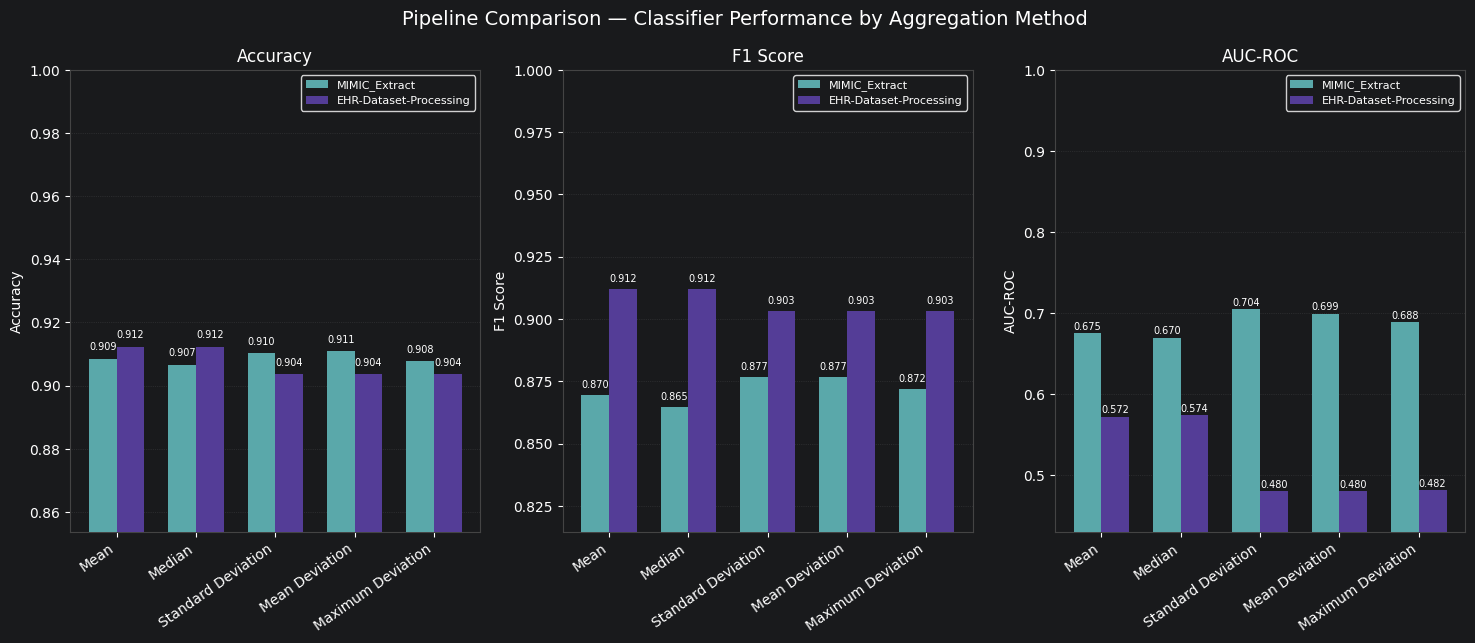

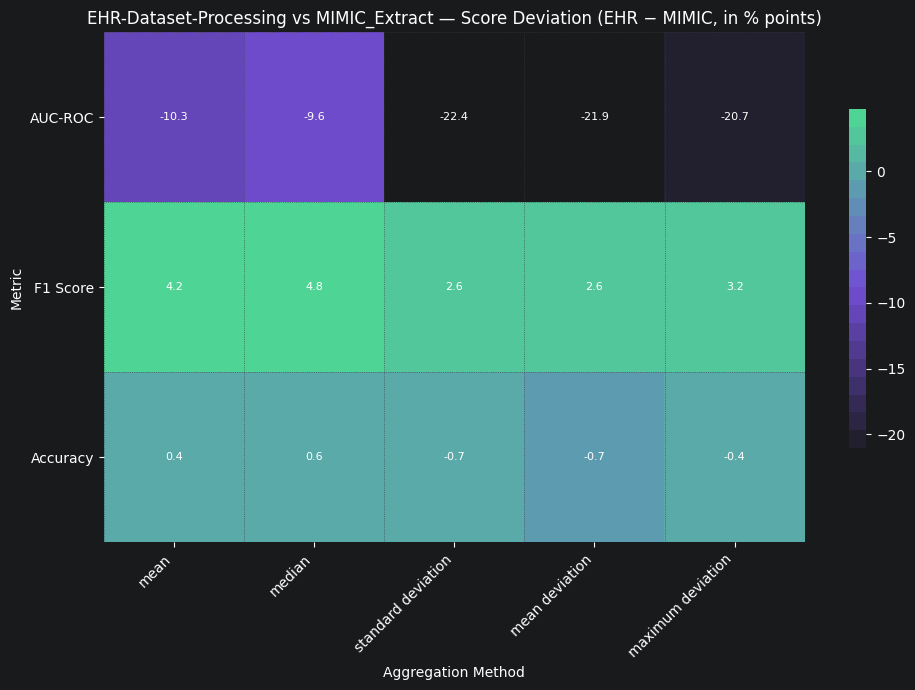

In [9]:
# ── Consolidated Pipeline Comparison: Accuracy, F1, AUC-ROC ────────────────
_metrics = [('Accuracy', 'acc'), ('F1 Score', 'f1'), ('AUC-ROC', 'auc')]
_n = len(AGG_METHODS)

_mimic_scores = {key: [float(np.mean(EVAL_RESULTS[m]['mimic'][key])) for m in AGG_METHODS]
                 for _, key in _metrics}
_ehr_scores   = {key: [float(np.nanmean(EVAL_RESULTS[m]['ehr'][key])) for m in AGG_METHODS]
                 for _, key in _metrics}

_grad      = generate_hex_gradient(_AURORA, 7)
_col_mimic = _grad[5]   # aurora teal
_col_ehr   = _grad[2]   # aurora purple

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor=_BG)
fig.suptitle('Pipeline Comparison — Classifier Performance by Aggregation Method',
             color='white', fontsize=14)

_x = np.arange(_n)
_w = 0.35

for ax, (label, key) in zip(axes, _metrics):
    ax.set_facecolor(_BG)
    bars_m = ax.bar(_x - _w/2, _mimic_scores[key], _w,
                    label='MIMIC_Extract', color=_col_mimic, zorder=3)
    bars_e = ax.bar(_x + _w/2, _ehr_scores[key],   _w,
                    label='EHR-Dataset-Processing', color=_col_ehr, zorder=3)
    for bar in list(bars_m) + list(bars_e):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.002, f'{h:.3f}',
                ha='center', va='bottom', color='white', fontsize=7)
    ax.set_xticks(_x)
    ax.set_xticklabels([m.title() for m in AGG_METHODS], rotation=35, ha='right', color='white')
    ax.set_ylabel(label, color='white')
    ax.set_title(label, color='white', fontsize=12)
    ax.tick_params(colors='white')
    ax.grid(axis='y', color='#3a3b3d', linestyle=':', linewidth=0.5, zorder=0)
    for sp in ax.spines.values():
        sp.set_color('#444444')
    _ymin = min(min(_mimic_scores[key]), min(_ehr_scores[key]))
    ax.set_ylim(max(0, _ymin - 0.05), 1.0)
    ax.legend(facecolor=_BG, labelcolor='white', fontsize=8)

plt.subplots_adjust(top=0.88)
plt.show()

# ── Deviation heatmap: EHR − MIMIC per (metric × aggregation method) ──────────────
# Scaled to percentage points so annotation format ({v:.1f}) shows meaningful values.
_dev_data = {label: [((_ehr_scores[key][i] - _mimic_scores[key][i]) * 100) for i in range(_n)]
             for label, key in _metrics}
df_dev = pd.DataFrame(_dev_data, index=AGG_METHODS).T  # metrics × methods

generate_heatmap(df_dev,
    title='EHR-Dataset-Processing vs MIMIC_Extract — Score Deviation (EHR − MIMIC, in % points)',
    x_title='Aggregation Method', y_title='Metric', annotate=True)


## McNemar's Test

Test whether the two pipelines' predictions on shared test patients differ
significantly. Discordant counts pooled across 4 seeds.

mean                      n01=  21  n10=  92  p=0.0000
median                    n01=  47  n10=  23  p=0.0056
standard deviation        n01=  80  n10= 179  p=0.0000
mean deviation            n01=  62  n10= 190  p=0.0000
maximum deviation         n01= 102  n10= 102  p=1.0000


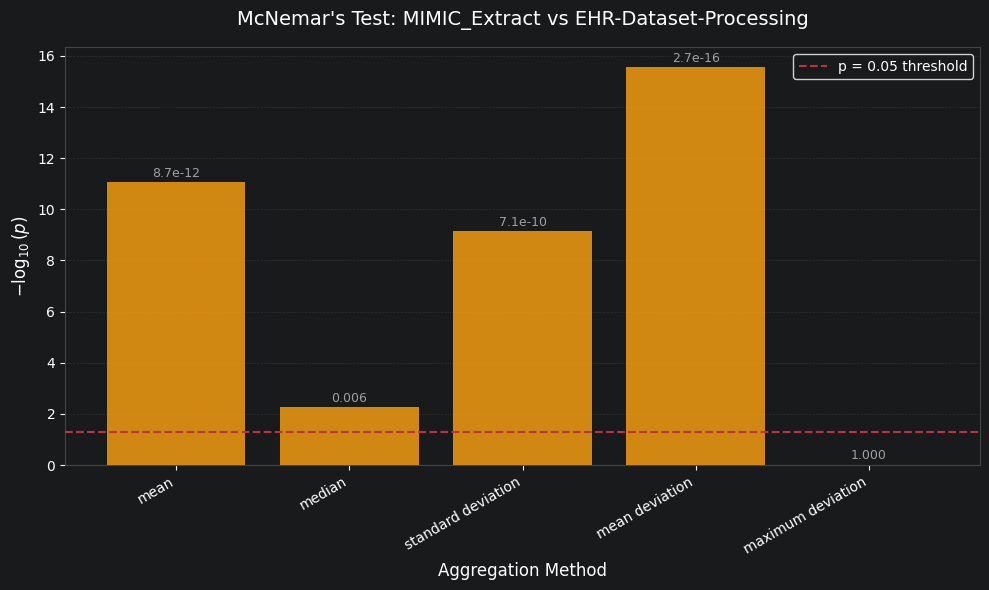

In [10]:
mcnemar_p_values = []

for method in AGG_METHODS:
    mimic_res = EVAL_RESULTS[method]['mimic']
    ehr_res   = EVAL_RESULTS[method]['ehr']
    total_n01, total_n10 = 0, 0
    for seed_idx in range(len(SEEDS)):
        yte    = mimic_res['y_test_list'][seed_idx]
        pred_m = mimic_res['preds'][seed_idx]
        pred_e = ehr_res['preds'][seed_idx]
        n01, n10 = mcnemar_counts(yte, pred_m, pred_e)
        total_n01 += n01
        total_n10 += n10
    _, p = mcnemar_pooled(total_n01, total_n10)
    mcnemar_p_values.append(p)
    print(f'{method:<25} n01={total_n01:4d}  n10={total_n10:4d}  p={p:.4f}')

visualize_mcnemar_significance(
    p_values = mcnemar_p_values,
    names    = AGG_METHODS,
    title    = 'McNemar\'s Test: MIMIC_Extract vs EHR-Dataset-Processing',
)

## Per-Vital Feature Distribution Comparison

Centroid shift: for each aggregation method, compare the mean feature value
per vital across both pipelines on the shared cohort.


=== mean ===
  heart rate                          MIMIC=  83.850  EHR=  84.084  Δ=+0.234
  systolic blood pressure             MIMIC= 119.813  EHR= 120.298  Δ=+0.485
  diastolic blood pressure            MIMIC=  61.187  EHR=  61.998  Δ=+0.811
  mean blood pressure                 MIMIC=  78.652  EHR=  79.205  Δ=+0.553
  respiratory rate                    MIMIC=  18.305  EHR=  21.107  Δ=+2.802
  temperature                         MIMIC=  36.852  EHR=  36.773  Δ=-0.079
  oxygen saturation                   MIMIC=  96.985  EHR=  98.883  Δ=+1.898


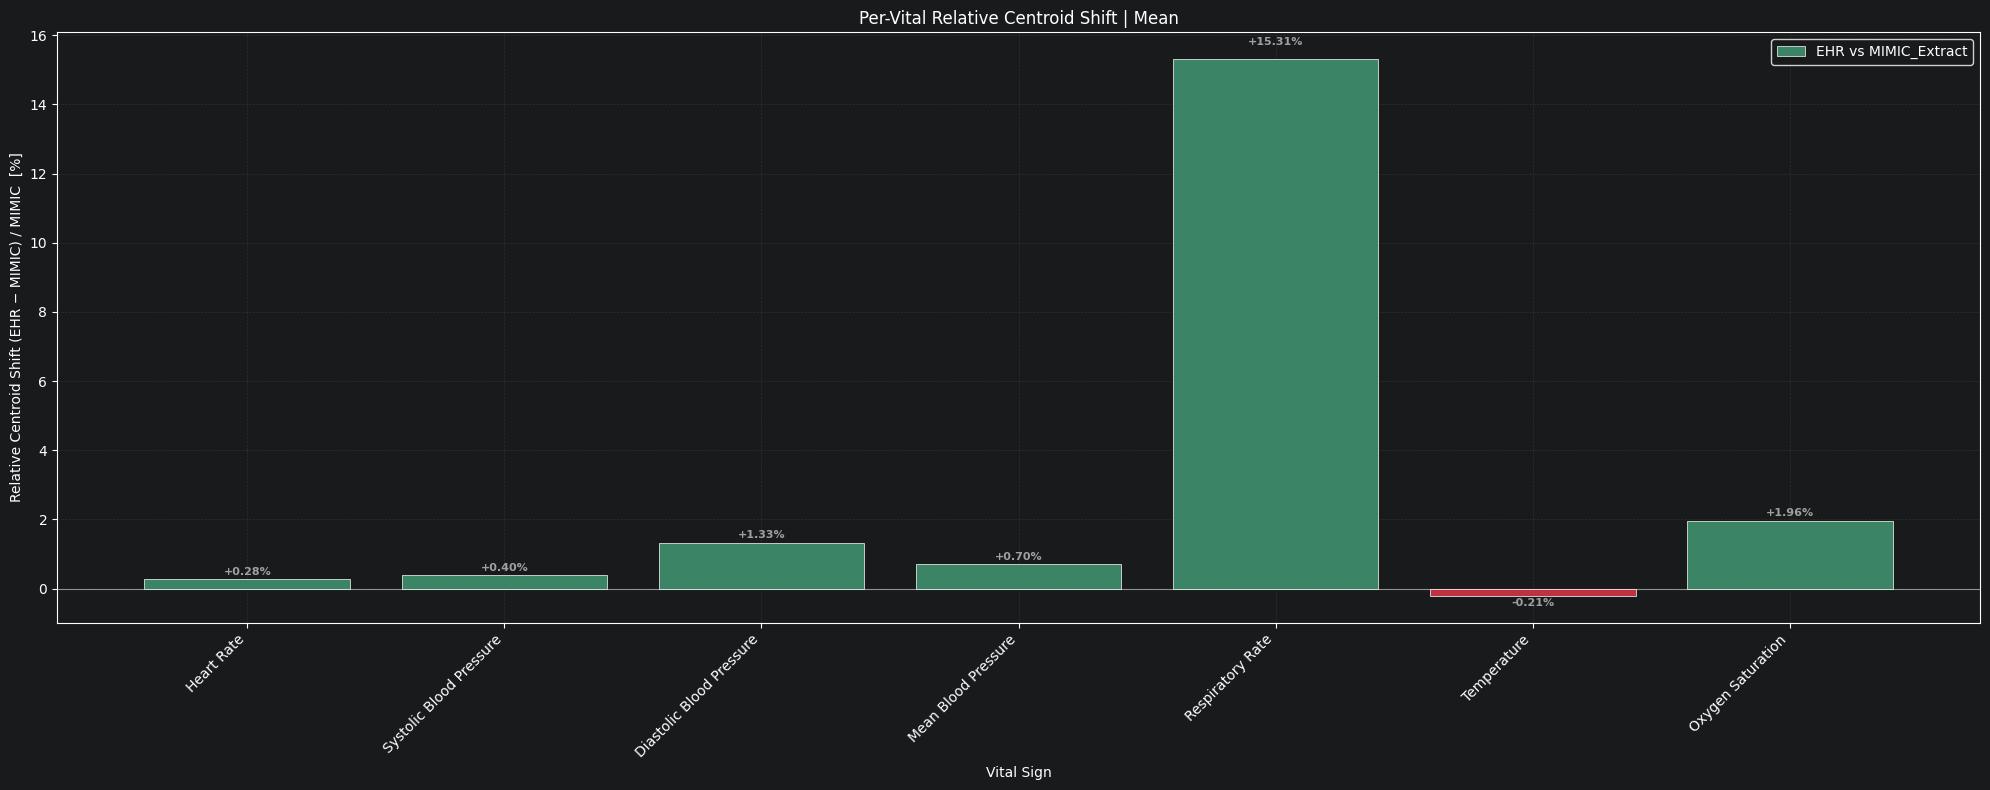


=== median ===
  heart rate                          MIMIC=  83.315  EHR=  83.517  Δ=+0.202
  systolic blood pressure             MIMIC= 119.517  EHR= 119.569  Δ=+0.051
  diastolic blood pressure            MIMIC=  60.608  EHR=  60.892  Δ=+0.284
  mean blood pressure                 MIMIC=  78.066  EHR=  78.264  Δ=+0.197
  respiratory rate                    MIMIC=  18.212  EHR=  18.152  Δ=-0.061
  temperature                         MIMIC=  36.880  EHR=  36.817  Δ=-0.062
  oxygen saturation                   MIMIC=  97.379  EHR=  97.634  Δ=+0.254


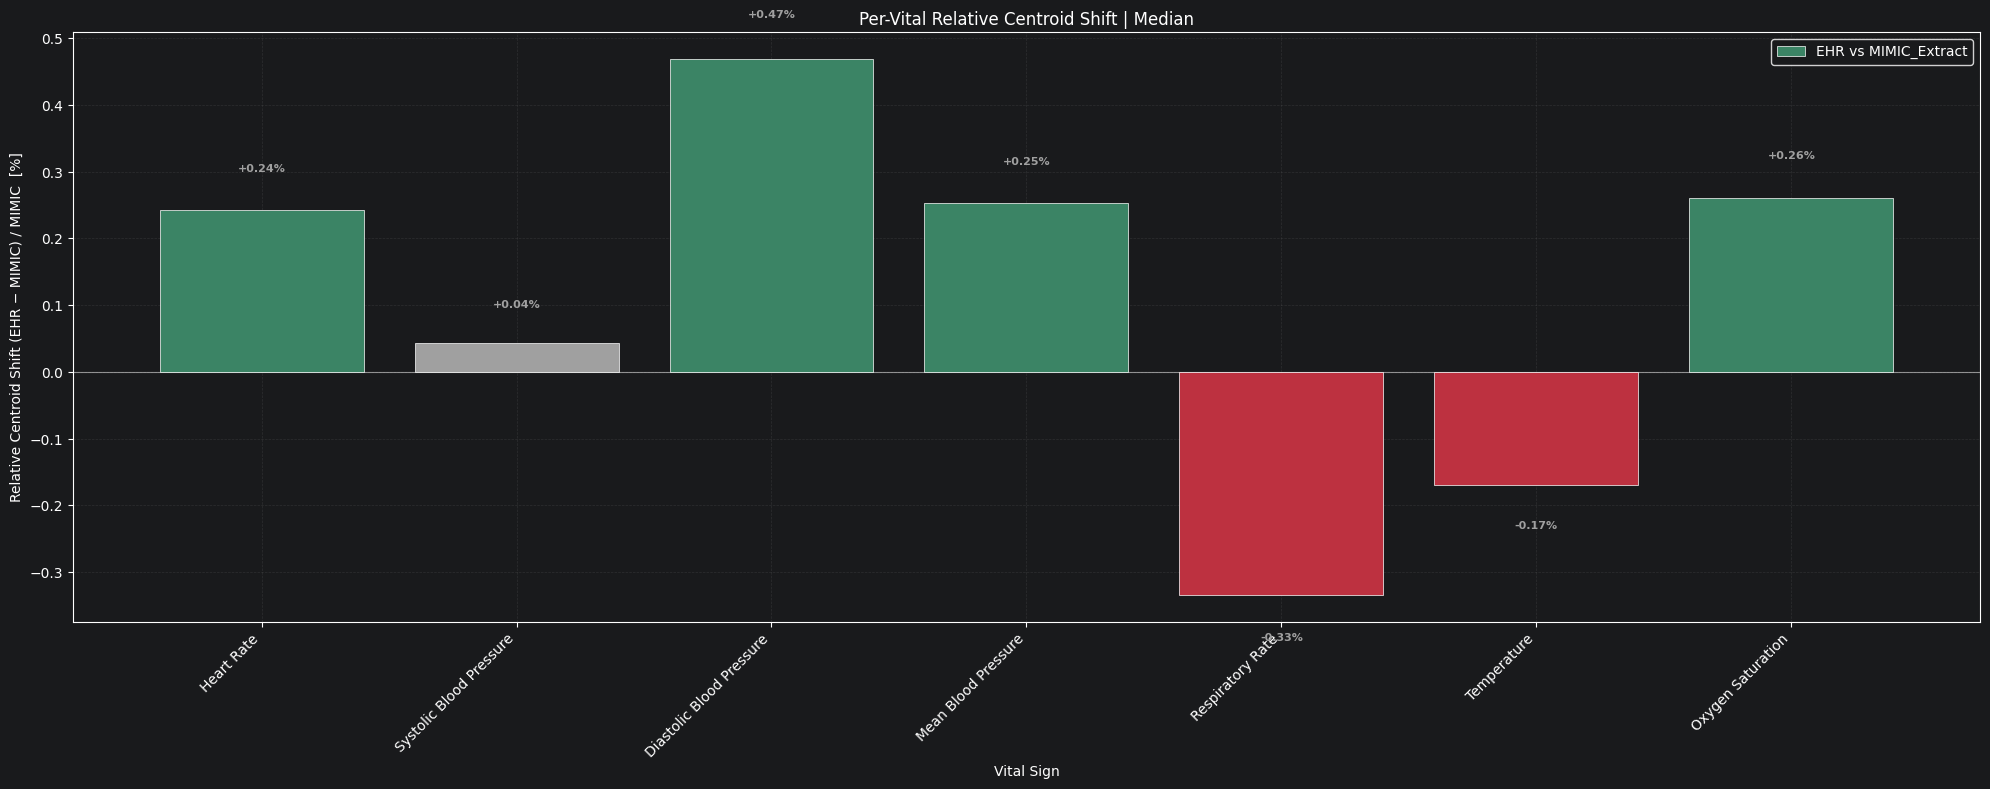


=== standard deviation ===
  heart rate                          MIMIC=   8.000  EHR=   8.315  Δ=+0.315
  systolic blood pressure             MIMIC=  12.785  EHR=  16.204  Δ=+3.420
  diastolic blood pressure            MIMIC=   8.755  EHR=  12.227  Δ=+3.472
  mean blood pressure                 MIMIC=   9.555  EHR=  11.914  Δ=+2.359
  respiratory rate                    MIMIC=   3.668  EHR=  18.998  Δ=+15.330
  temperature                         MIMIC=   0.490  EHR=   0.614  Δ=+0.124
  oxygen saturation                   MIMIC=   2.158  EHR=   9.691  Δ=+7.533


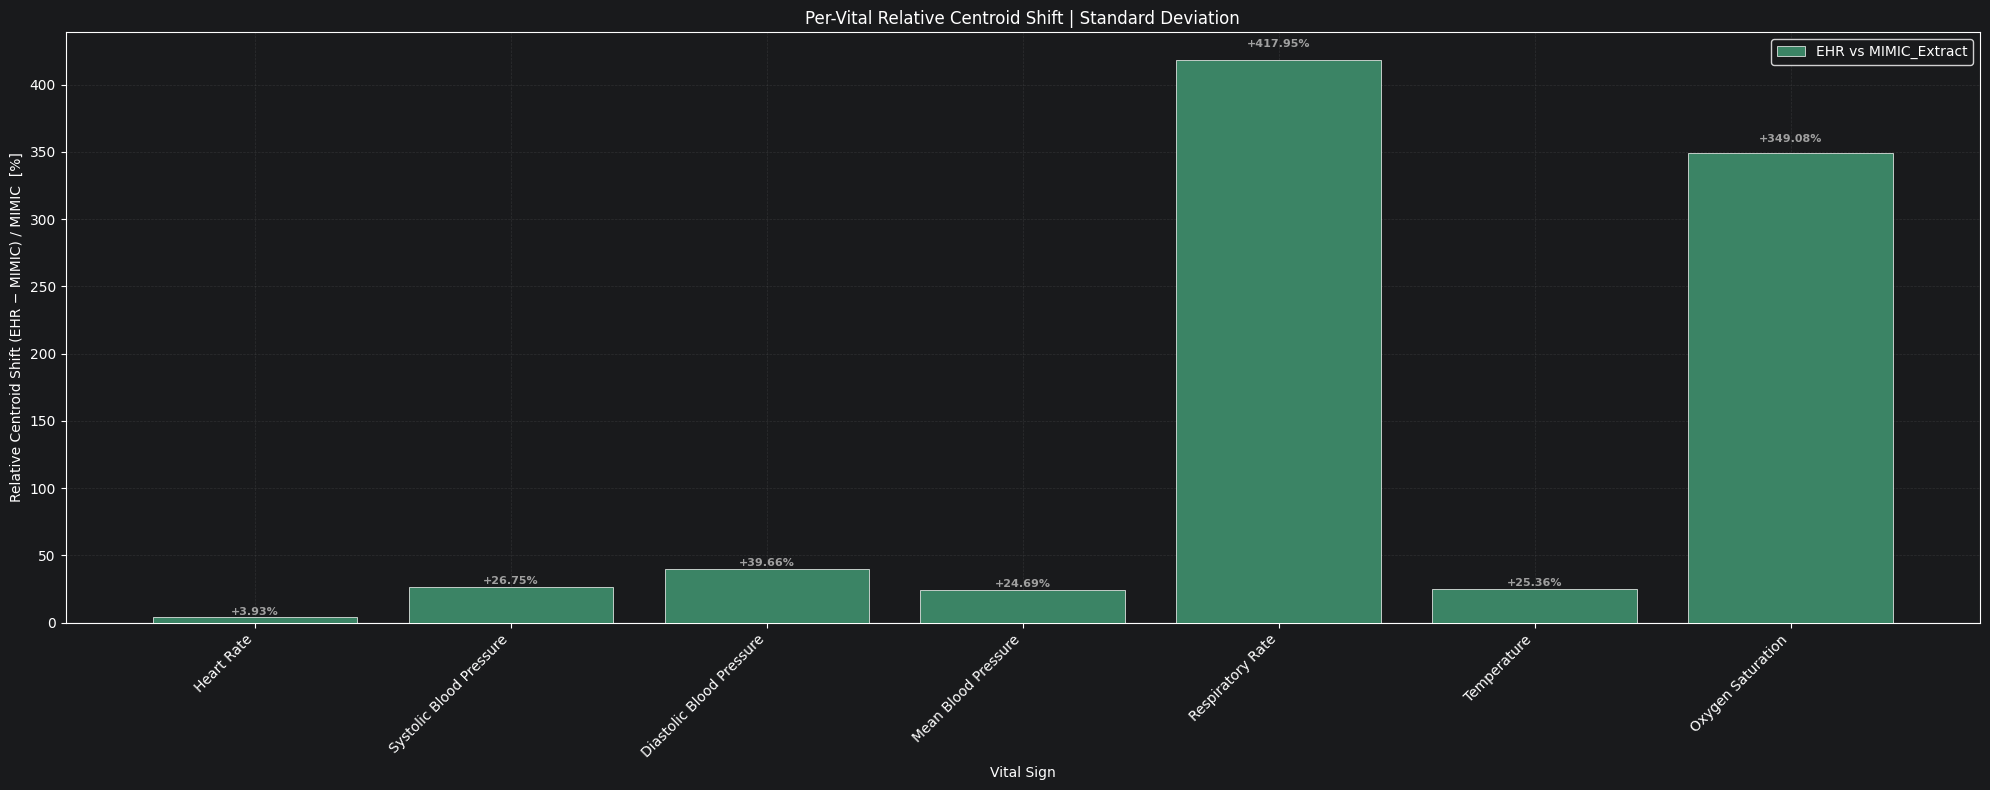


=== mean deviation ===
  heart rate                          MIMIC=   6.318  EHR=   6.552  Δ=+0.234
  systolic blood pressure             MIMIC=   9.979  EHR=  11.763  Δ=+1.784
  diastolic blood pressure            MIMIC=   6.634  EHR=   8.133  Δ=+1.499
  mean blood pressure                 MIMIC=   7.249  EHR=   8.468  Δ=+1.219
  respiratory rate                    MIMIC=   2.835  EHR=   8.006  Δ=+5.171
  temperature                         MIMIC=   0.374  EHR=   0.452  Δ=+0.078
  oxygen saturation                   MIMIC=   1.567  EHR=   4.511  Δ=+2.944


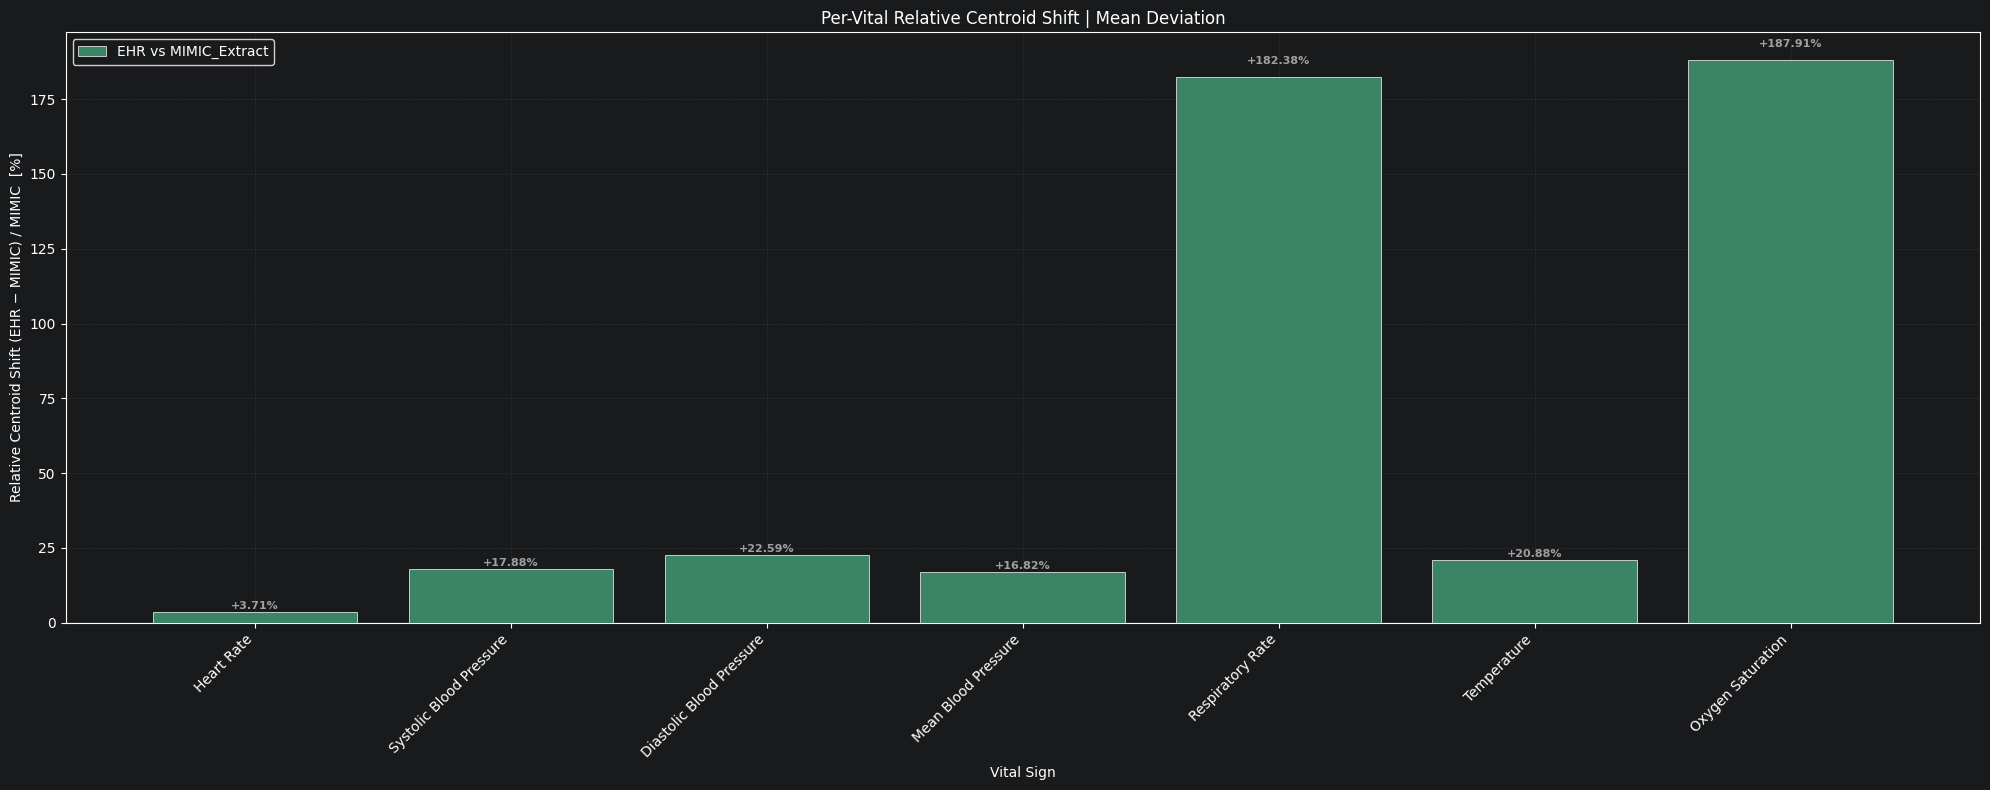


=== maximum deviation ===
  heart rate                          MIMIC=  17.613  EHR=  18.892  Δ=+1.279
  systolic blood pressure             MIMIC=  28.510  EHR=  42.632  Δ=+14.122
  diastolic blood pressure            MIMIC=  21.087  EHR=  38.093  Δ=+17.005
  mean blood pressure                 MIMIC=  22.898  EHR=  33.406  Δ=+10.508
  respiratory rate                    MIMIC=   8.380  EHR=  92.829  Δ=+84.449
  temperature                         MIMIC=   0.805  EHR=   1.042  Δ=+0.237
  oxygen saturation                   MIMIC=   5.690  EHR=  40.662  Δ=+34.972


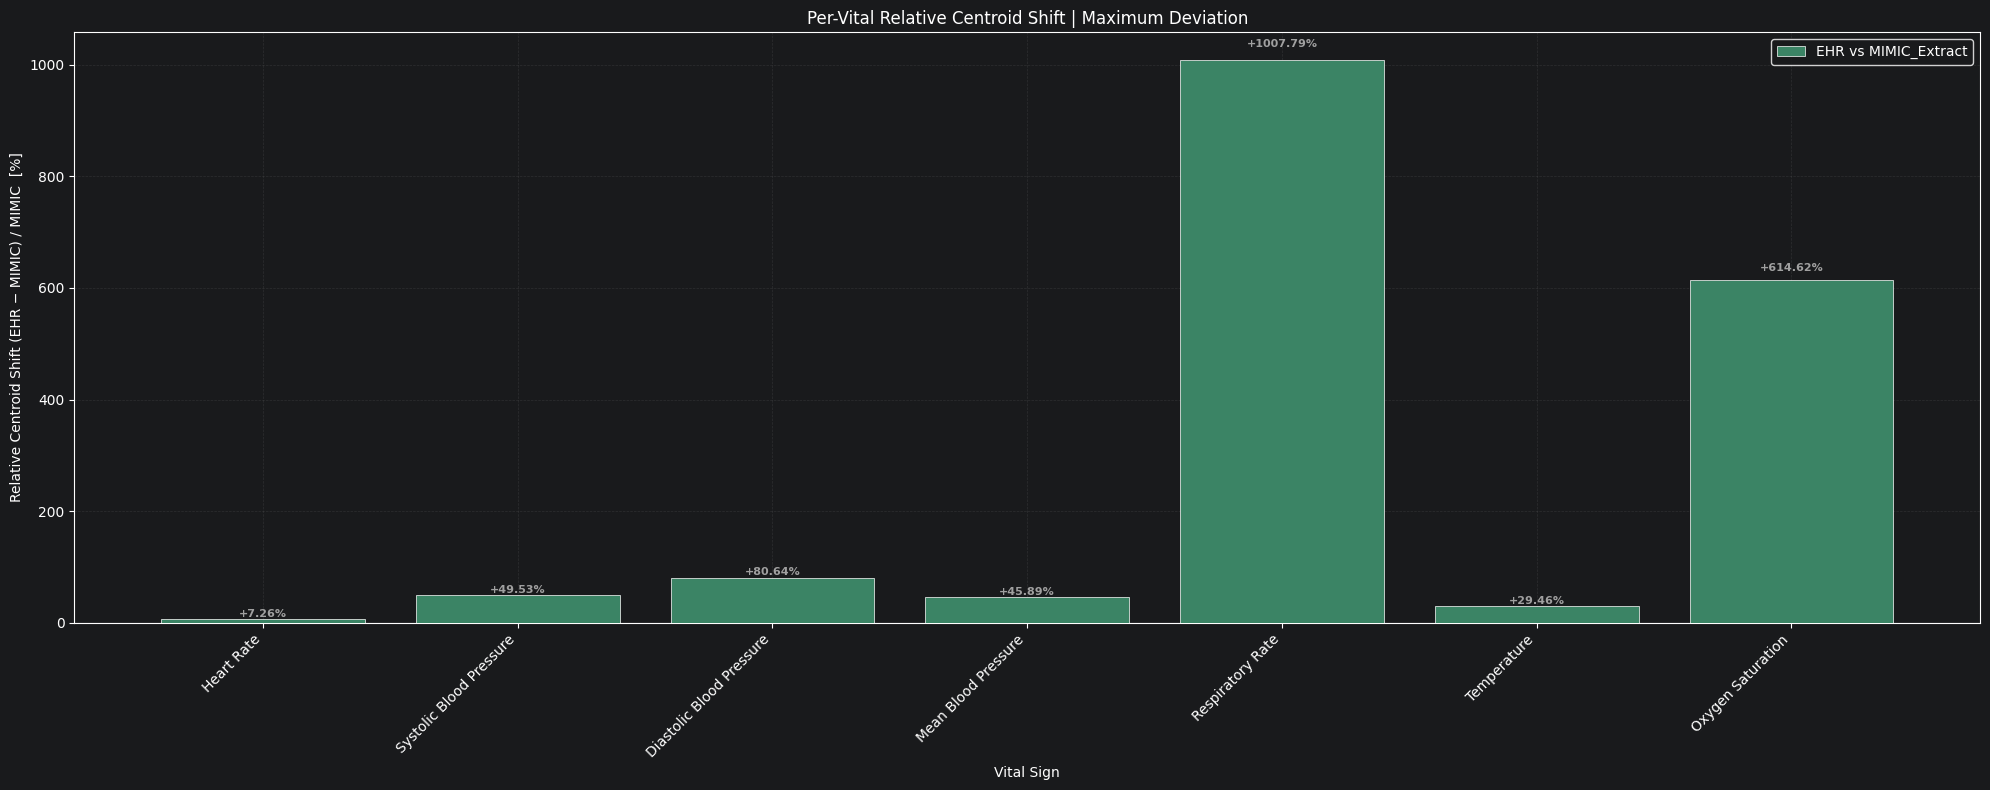

In [11]:
for method in AGG_METHODS:
    X_mimic = FEATURE_MATRICES[method]['mimic']
    X_ehr   = FEATURE_MATRICES[method]['ehr']

    def _imputed_means(X):
        X2 = X.replace([np.inf, -np.inf], np.nan)
        col_means = X2.mean(skipna=True).fillna(0.0)
        X2 = X2.fillna(col_means)
        return X2.mean(axis=0).values

    centroid_m = _imputed_means(X_mimic)
    centroid_e = _imputed_means(X_ehr)

    print(f'\n=== {method} ===')
    for vn, vm, ve in zip(VITAL_NAMES, centroid_m, centroid_e):
        print(f'  {vn:<35} MIMIC={vm:8.3f}  EHR={ve:8.3f}  Δ={ve-vm:+.3f}')

    visualize_centroid_shift_v2(
        shift_tuples  = [([centroid_m[i] for i in range(len(VITAL_NAMES))],
                          [centroid_e[i] for i in range(len(VITAL_NAMES))])],
        titles        = ['EHR vs MIMIC_Extract'],
        scenario_name = method.title(),
        vital_names   = VITAL_NAMES,
        relative      = True,
    )

## MIMIC_Extract Scenario Analysis

How each cohort filter variant compares to the unfiltered baseline across vital
distributions and classifier performance.

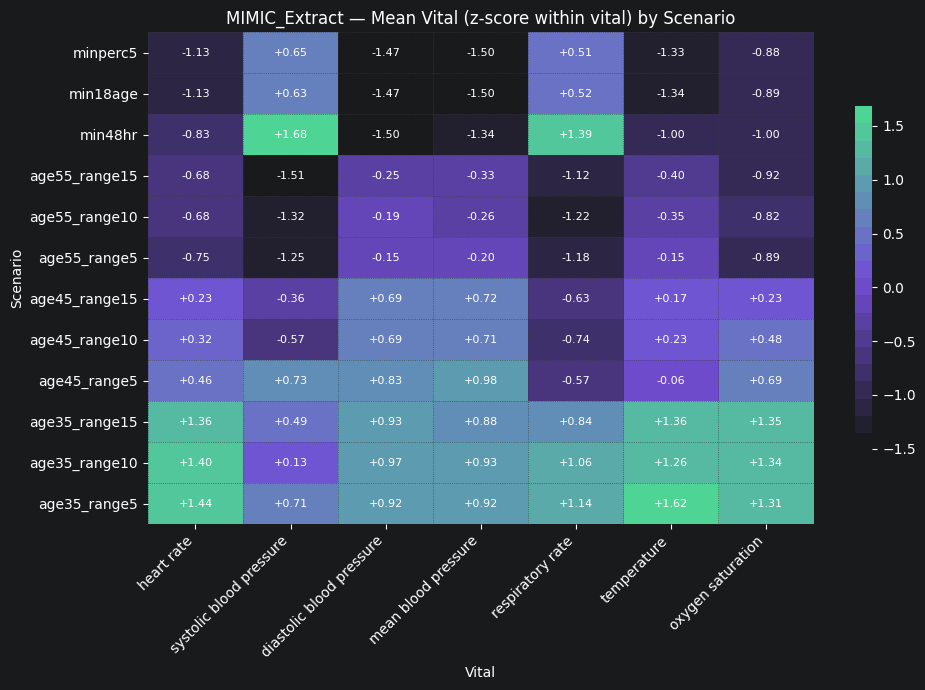

In [12]:
# ── MIMIC vital means heatmap (scenarios × vitals, z-scored within vital) ────
_sc_list   = [s for s in MIMIC_SCENARIO_LABELS if s != 'raw']
_vit_list  = [
    'heart rate', 'systolic blood pressure', 'diastolic blood pressure',
    'mean blood pressure', 'respiratory rate', 'temperature', 'oxygen saturation',
]
_stats_key_map = {'raw': 'baseline_nofilters'}
_rows = {}
for sc in _sc_list:
    _sk = _stats_key_map.get(sc, sc)
    _rows[sc] = {
        v: MIMIC_VITAL_STATS.get(_sk, {}).get('variables', {}).get(v, {}).get('mean', np.nan)
        for v in _vit_list
    }
df_mimic_vit = pd.DataFrame(_rows).T  # scenarios × vitals

# Z-score each vital column independently so scenario differences are visible
# instead of being swamped by the 17 → 121 inter-vital spread.
_col_std = df_mimic_vit.std().replace(0, np.nan)
df_mimic_vit_z = (df_mimic_vit - df_mimic_vit.mean()) / _col_std

generate_heatmap(
    df_mimic_vit_z,
    title='MIMIC_Extract — Mean Vital (z-score within vital) by Scenario',
    x_title='Vital', y_title='Scenario',
    annotate=True, fmt='{v:+.2f}',
)

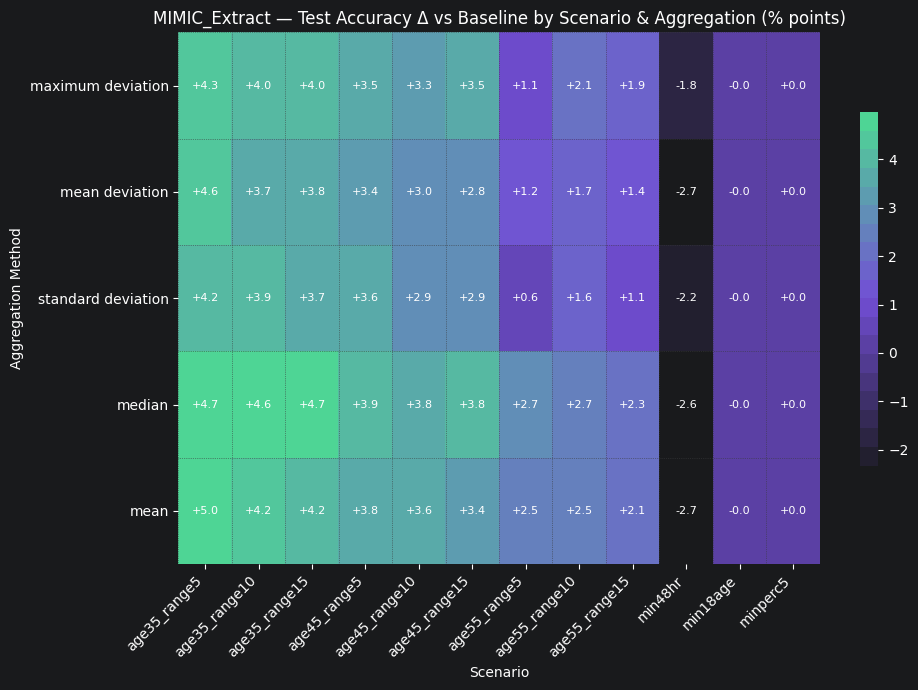

In [13]:
# ── MIMIC accuracy deviation heatmap (methods × scenarios, in % points) ─────
_dev = {}
for method in AGG_METHODS:
    _base = MIMIC_SCENARIO_IMPACT[method]['raw']['test_acc']
    _dev[method] = {
        sc: (MIMIC_SCENARIO_IMPACT[method].get(sc, {}).get('test_acc', np.nan) - _base)
        for sc in _sc_list
    }
df_mimic_dev = pd.DataFrame(_dev, index=_sc_list).T  # methods × scenarios

# Scale to percentage points so the {:+.1f} annotation is readable
# (raw Δacc values cluster around 0.04–0.05 and round to "0.0").
df_mimic_dev_pp = df_mimic_dev * 100.0

generate_heatmap(
    df_mimic_dev_pp,
    title='MIMIC_Extract — Test Accuracy Δ vs Baseline by Scenario & Aggregation (% points)',
    x_title='Scenario', y_title='Aggregation Method',
    annotate=True, fmt='{v:+.1f}',
)

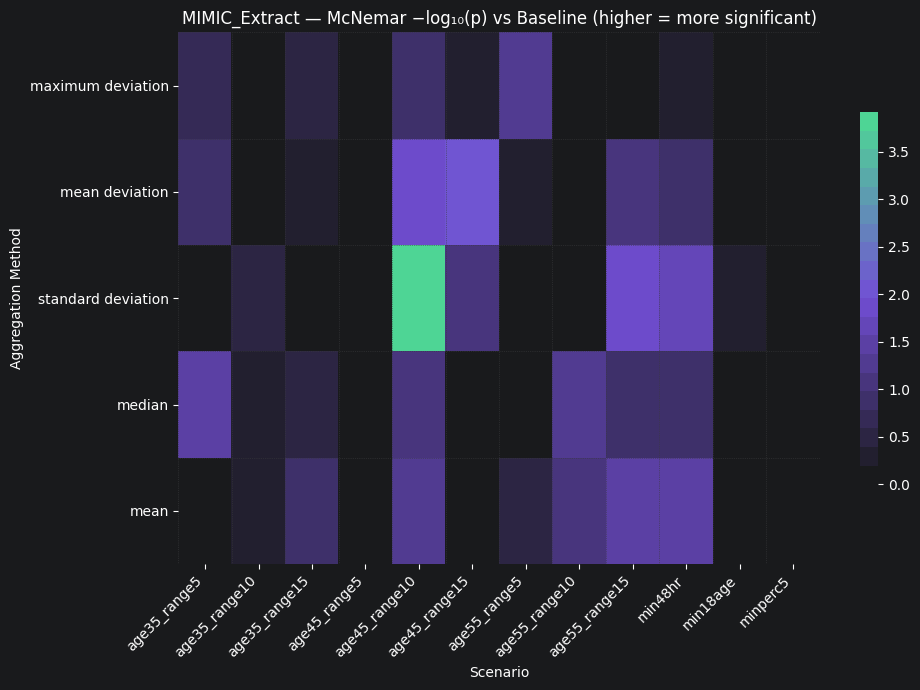

In [14]:
# ── MIMIC McNemar −log₁₀(p) heatmap (methods × scenarios) ─────────────────────
_pvals = {}
for method in AGG_METHODS:
    _pvals[method] = []
    for sc in _sc_list:
        mnm = MIMIC_SCENARIO_IMPACT[method].get(sc, {}).get('mcnemar')
        _pvals[method].append(mnm[1] if (mnm and mnm[1] is not None) else 1.0)
df_pval = pd.DataFrame(_pvals, index=_sc_list).T
df_logp = -np.log10(df_pval.clip(lower=1e-10))
generate_heatmap(
    df_logp,
    title='MIMIC_Extract — McNemar −log₁₀(p) vs Baseline (higher = more significant)',
    x_title='Scenario', y_title='Aggregation Method',
    annotate=False,
)

## EHR-Dataset-Processing Filter Pipeline Analysis

How each cumulative filter step shifts classifier performance.  
Results from the pre-computed GPU pipeline (cuML RandomForest on the full EHR cohort).

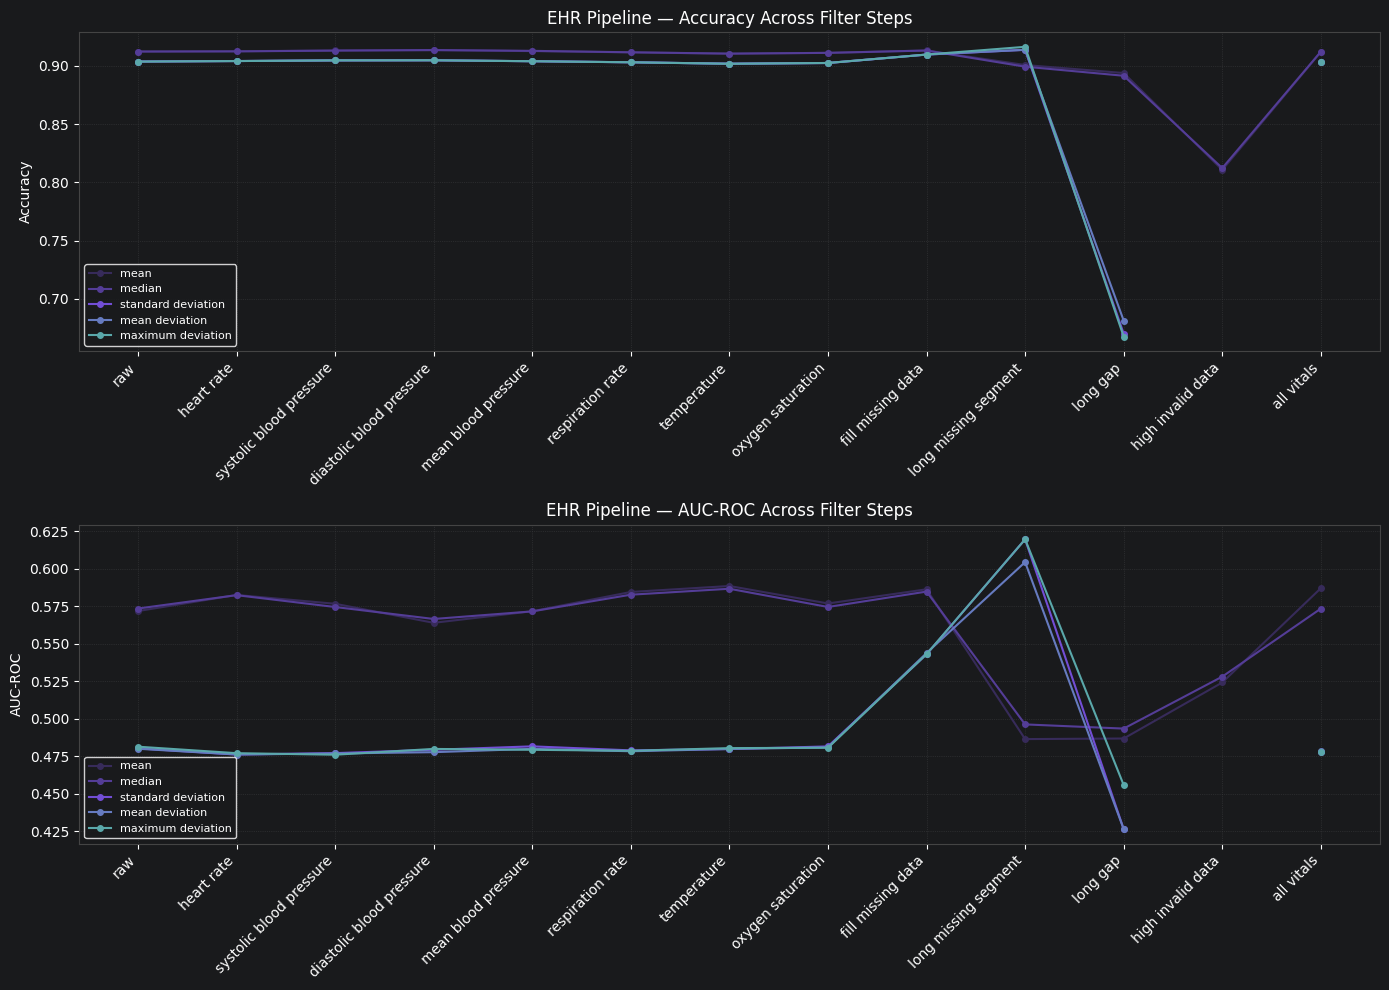

In [15]:
# ── EHR filter step line charts (accuracy and AUC-ROC) ───────────────────────
# Upstream pkl has literal 0.0 entries for failed cuML runs (acc[11]/auc[11] in
# the deviation-based methods); mask those as NaN so plots show a gap rather
# than a spurious dive to zero.
def _mask_failed(arr):
    a = np.array(arr, dtype=float)
    a[a == 0.0] = np.nan
    return a

fig, axes = plt.subplots(2, 1, figsize=(14, 10), facecolor=_BG)
_grad = generate_hex_gradient(_AURORA, len(AGG_METHODS) + 2)[1:-1]
for i, method in enumerate(AGG_METHODS):
    _imp = EHR_FILTER_IMPACT[method]
    _acc = _mask_failed(_imp['acc'])
    _auc = _mask_failed(_imp['auc'])
    _x   = list(range(len(_acc)))
    axes[0].plot(_x, _acc, color=_grad[i], marker='o', markersize=4, label=method)
    axes[1].plot(_x, _auc, color=_grad[i], marker='o', markersize=4, label=method)
for ax, ylabel, title in zip(
    axes,
    ['Accuracy', 'AUC-ROC'],
    ['EHR Pipeline — Accuracy Across Filter Steps',
     'EHR Pipeline — AUC-ROC Across Filter Steps'],
):
    ax.set_facecolor(_BG)
    ax.set_xticks(range(len(EHR_FILTER_LABELS)))
    ax.set_xticklabels(EHR_FILTER_LABELS, rotation=45, ha='right', color='white')
    ax.set_ylabel(ylabel, color='white')
    ax.set_title(title, color='white')
    ax.tick_params(colors='white')
    ax.grid(color='#3a3b3d', linestyle=':', linewidth=0.5)
    ax.legend(facecolor=_BG, labelcolor='white', fontsize=8)
    for sp in ax.spines.values(): sp.set_color('#444444')
plt.tight_layout()
plt.show()

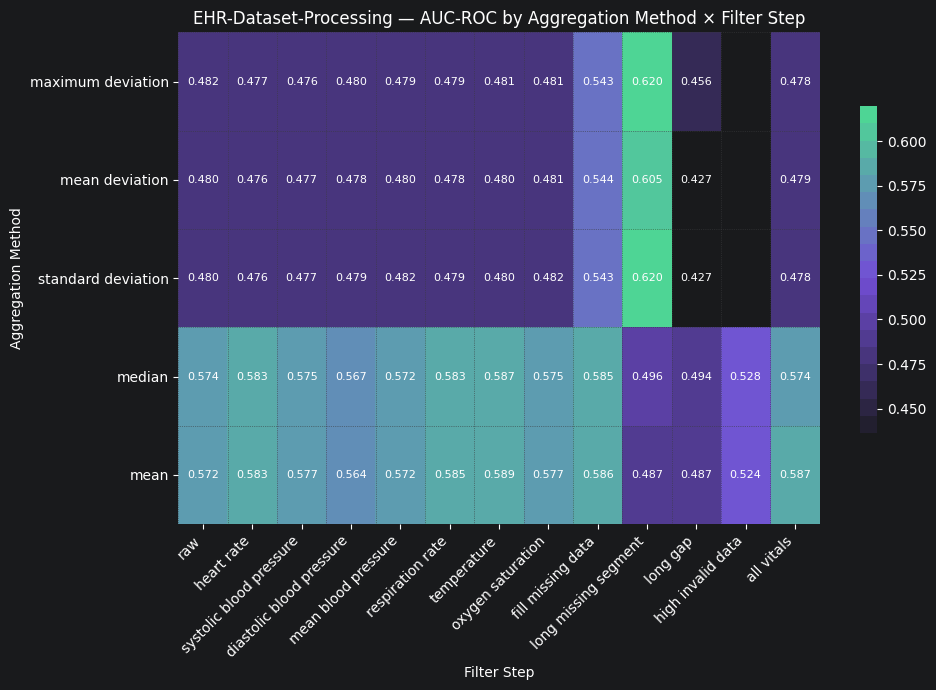

In [16]:
# ── EHR AUC heatmap (methods × filter steps, failed entries masked) ────────
_ehr_auc_rows = {}
for method in AGG_METHODS:
    _auc = np.array(EHR_FILTER_IMPACT[method]['auc'], dtype=float)
    _auc[_auc == 0.0] = np.nan   # failed upstream runs
    _ehr_auc_rows[method] = _auc
df_ehr_auc = pd.DataFrame(_ehr_auc_rows, index=EHR_FILTER_LABELS).T  # methods × filter steps
generate_heatmap(
    df_ehr_auc,
    title='EHR-Dataset-Processing — AUC-ROC by Aggregation Method × Filter Step',
    x_title='Filter Step', y_title='Aggregation Method',
    annotate=True, fmt='{v:.3f}',
)

## Cross-Pipeline: Deviation from Each Pipeline's Baseline

For each pipeline, every experiment (MIMIC: cohort variant, EHR: filter step) is
expressed as Δ accuracy relative to that pipeline's own unfiltered baseline.
This isolates the preprocessing effect from cohort-size effects.

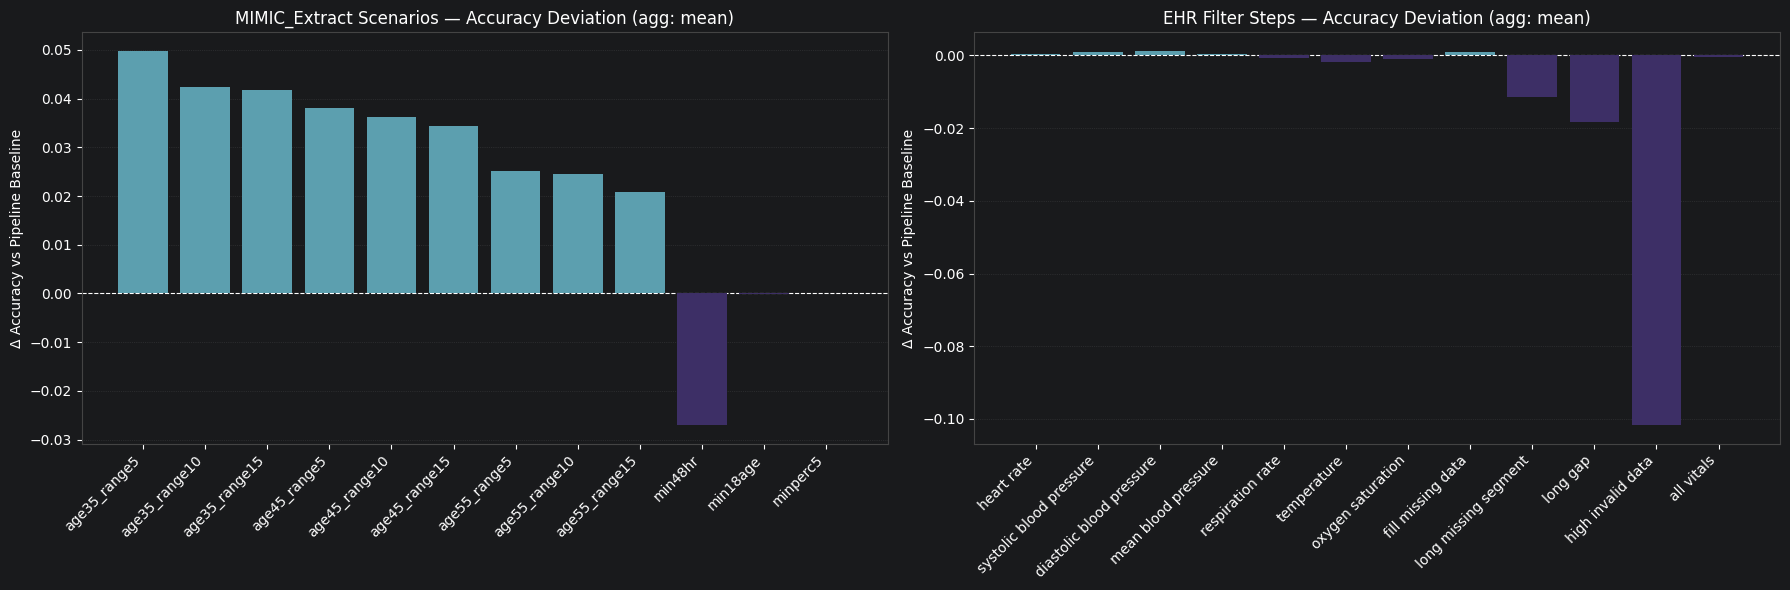

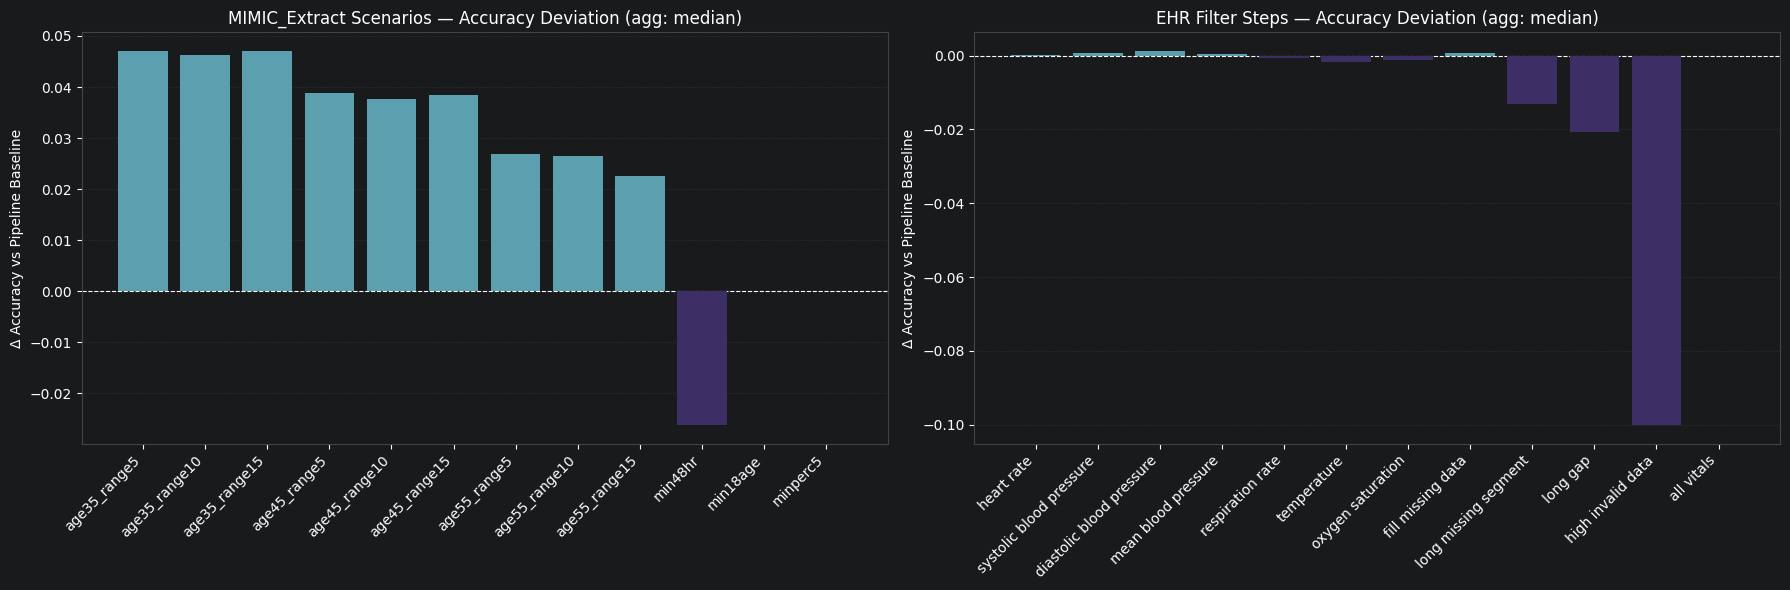

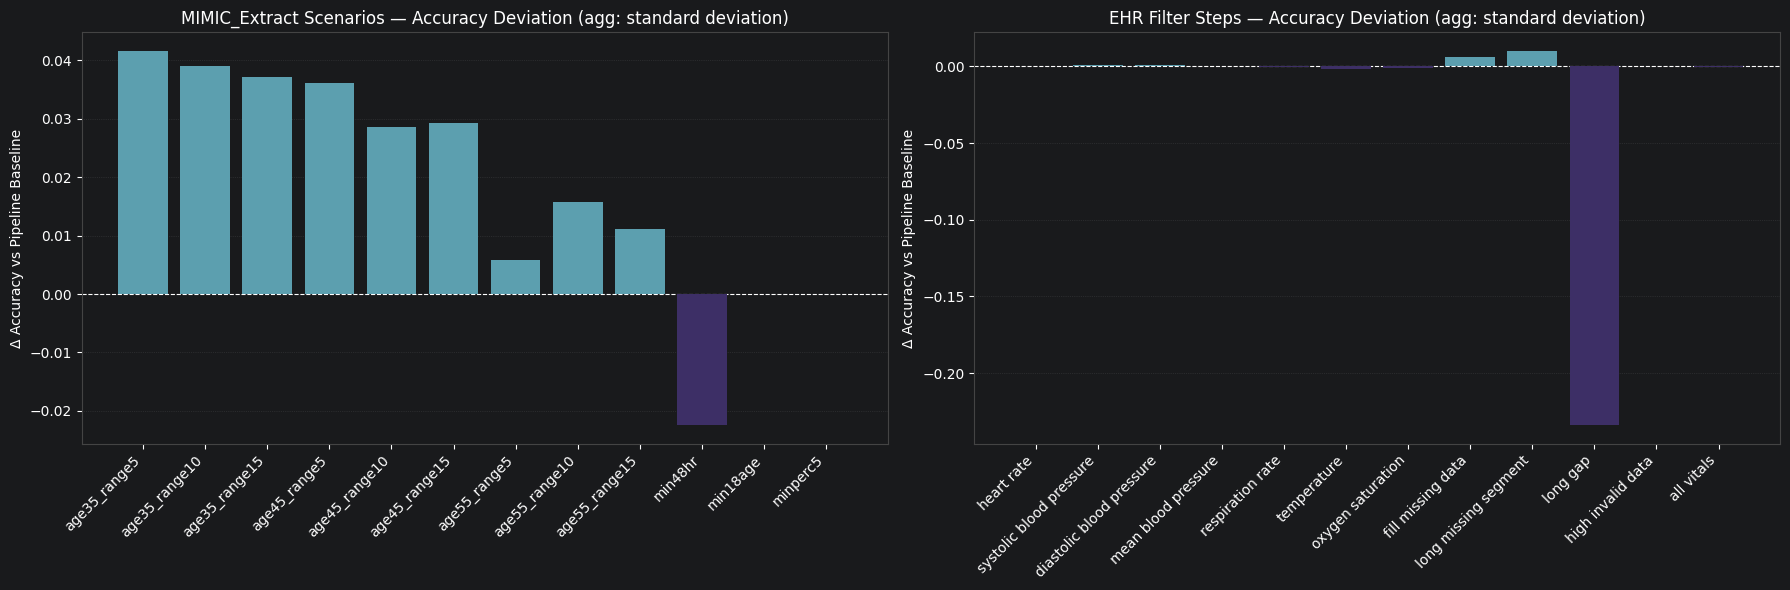

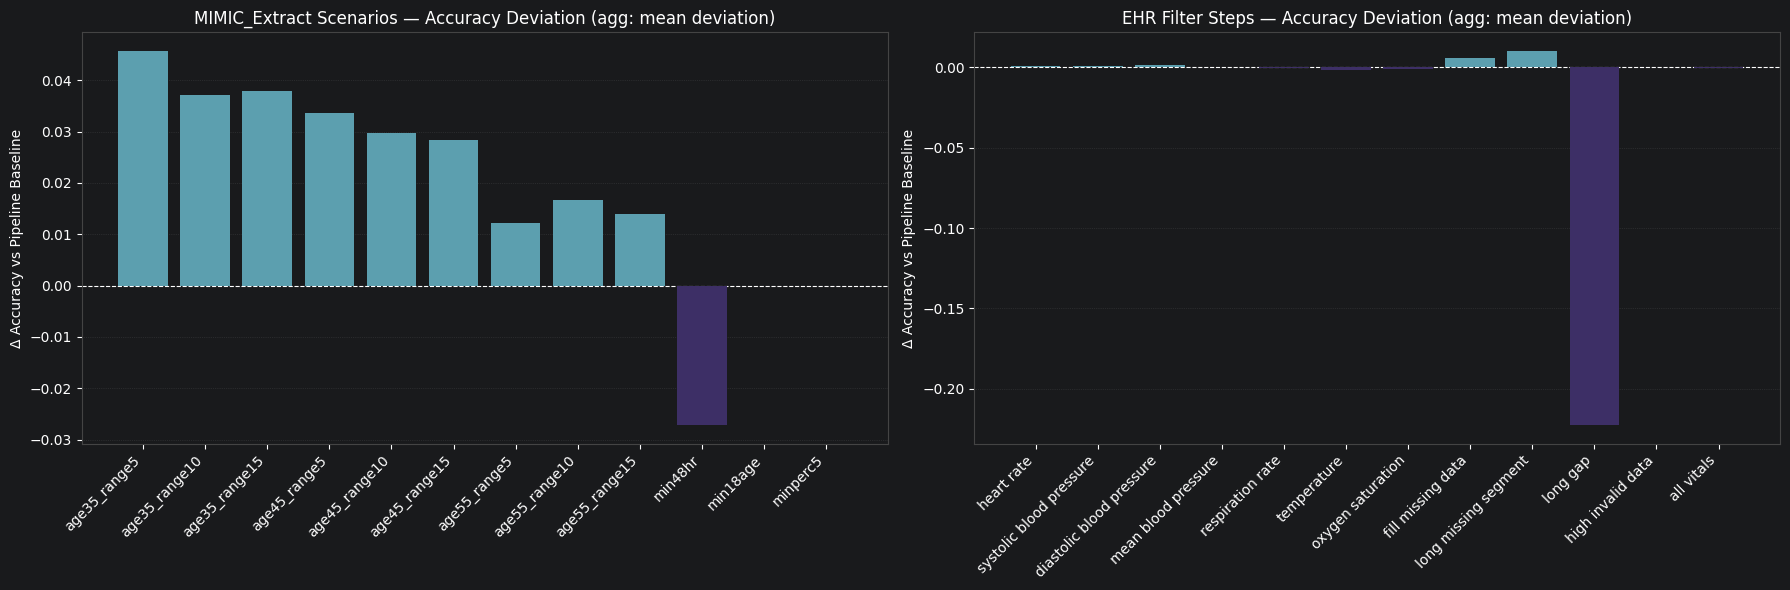

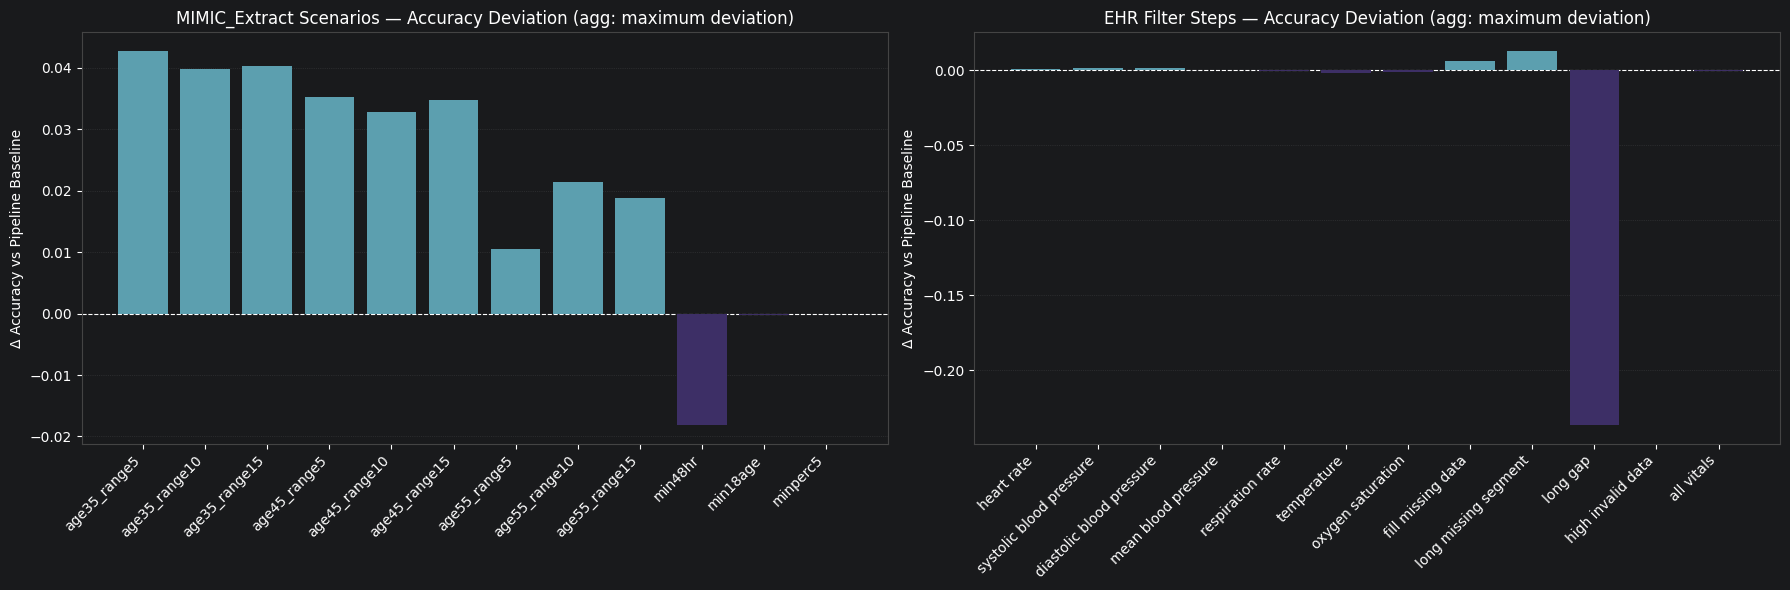

In [17]:
# ── Cross-pipeline deviation bar charts (one per aggregation method) ─────────
# EHR pkl has literal 0.0 entries for failed runs; mask before computing Δ so
# the bar at e.g. 'high invalid data' isn't a spurious −0.9 acc drop.
def _mask_failed(arr):
    a = np.array(arr, dtype=float)
    a[a == 0.0] = np.nan
    return a

_grad2 = generate_hex_gradient(_AURORA, 6)
for _method in AGG_METHODS:
    _mimic_devs = [
        MIMIC_SCENARIO_IMPACT[_method].get(sc, {}).get('test_acc', np.nan)
        - MIMIC_SCENARIO_IMPACT[_method]['raw']['test_acc']
        for sc in _sc_list
    ]
    _ehr_acc = _mask_failed(EHR_FILTER_IMPACT[_method]['acc'])
    _ehr_base = _ehr_acc[0]
    _ehr_devs = (_ehr_acc[1:] - _ehr_base).tolist()

    fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor=_BG)
    for ax, devs, labels, pipeline in zip(
        axes,
        [_mimic_devs, _ehr_devs],
        [_sc_list, EHR_FILTER_LABELS[1:]],
        ['MIMIC_Extract Scenarios', 'EHR Filter Steps'],
    ):
        ax.set_facecolor(_BG)
        # NaN-safe colour pick + heights
        heights = [0.0 if not np.isfinite(d) else d for d in devs]
        _colors = ['#a0a0a0' if not np.isfinite(d) else (_grad2[4] if d >= 0 else _grad2[1])
                   for d in devs]
        ax.bar(range(len(devs)), heights, color=_colors, zorder=3)
        ax.axhline(0, color='white', linewidth=0.8, linestyle='--')
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha='right', color='white')
        ax.set_ylabel('Δ Accuracy vs Pipeline Baseline', color='white')
        ax.set_title(f'{pipeline} — Accuracy Deviation (agg: {_method})', color='white')
        ax.tick_params(colors='white')
        ax.grid(axis='y', color='#3a3b3d', linestyle=':', linewidth=0.5)
        for sp in ax.spines.values(): sp.set_color('#444444')
    plt.tight_layout()
    plt.show()

## Summary Dashboard

Consolidated bar chart: MIMIC_Extract vs EHR-Dataset-Processing across
all 5 aggregation methods for Accuracy and F1.

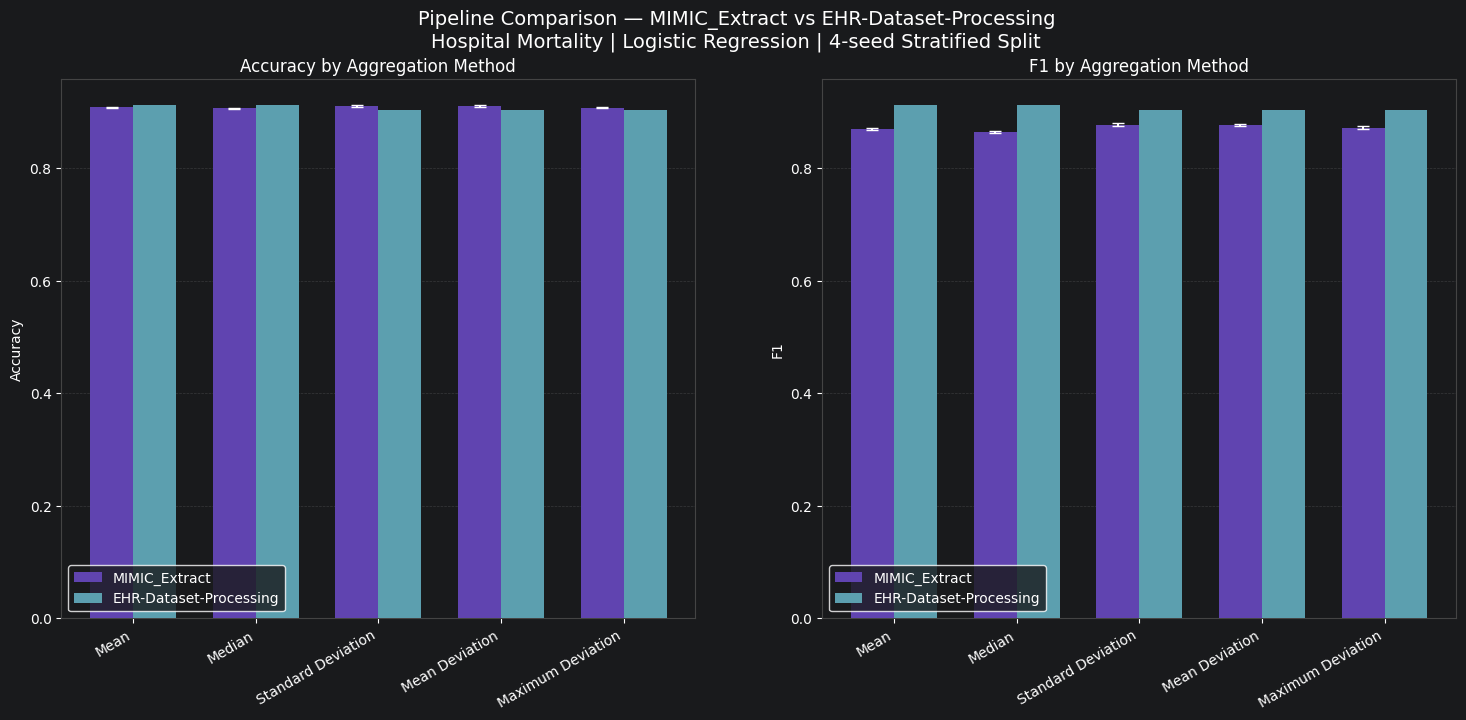

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor=_BG)
bar_w = 0.35
indices = np.arange(len(AGG_METHODS))
grad = generate_hex_gradient(_AURORA, 6)
colors_m = grad[2]  # mid-purple for MIMIC
colors_e = grad[4]  # teal/green for EHR

for ax_idx, (metric_key, metric_label) in enumerate([('acc', 'Accuracy'), ('f1', 'F1')]):
    ax = axes[ax_idx]
    ax.set_facecolor(_BG)
    mimic_scores = [np.mean(EVAL_RESULTS[m]['mimic'][metric_key]) for m in AGG_METHODS]
    ehr_scores   = [np.nanmean(EVAL_RESULTS[m]['ehr'][metric_key])   for m in AGG_METHODS]
    mimic_stds   = [np.std(EVAL_RESULTS[m]['mimic'][metric_key])   for m in AGG_METHODS]
    # EHR scalar metrics are overridden from the GPU pkl as single-value lists
    # (one cuML cv split), so np.std = 0. Suppress error whiskers instead of
    # rendering a misleading zero-width bar.
    ehr_stds     = None

    b1 = ax.bar(indices - bar_w/2, mimic_scores, bar_w,
                label='MIMIC_Extract', color=colors_m, yerr=mimic_stds,
                error_kw=dict(ecolor='white', capsize=4), zorder=3)
    b2 = ax.bar(indices + bar_w/2, ehr_scores, bar_w,
                label='EHR-Dataset-Processing', color=colors_e,
                zorder=3)

    ax.set_xticks(indices)
    ax.set_xticklabels([m.title() for m in AGG_METHODS], rotation=30, ha='right')
    ax.set_ylabel(metric_label, color='white')
    ax.set_title(f'{metric_label} by Aggregation Method', color='white')
    ax.grid(axis='y', color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
    for sp in ax.spines.values():
        sp.set_color('#444444')
    ax.legend(facecolor=_BG, labelcolor='white')

fig.suptitle('Pipeline Comparison — MIMIC_Extract vs EHR-Dataset-Processing\n'
             'Hospital Mortality | Logistic Regression | 4-seed Stratified Split',
             color='white', fontsize=14)
plt.subplots_adjust(top=0.88)
plt.show()